# Import libraries

In [2]:
import os
import warnings
import itertools
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import pearsonr, spearmanr, linregress, t, ttest_ind, f_oneway, pearsonr
pd.options.mode.chained_assignment = None
import seaborn as sns

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
from statsmodels.formula.api import mixedlm
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
import datetime
from tigramite.independence_tests import cmiknn
import pingouin as pg

os.environ['CASTLE_BACKEND'] = 'pytorch'
import castle
from castle.common import GraphDAG, independence_tests
from castle.metrics import MetricsDAG
from castle.datasets import IIDSimulation, DAG
from castle.algorithms import PC, GES, ICALiNGAM, GOLEM
from collections import OrderedDict

warnings.filterwarnings("ignore")


2026-07-13 12:25:02,527 - /Users/ronibarakventura/Desktop/National Collaborative on Gun Violence Research/Projects/Urban Scaling/data-analysis-guns-and-women/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


# Define functions

### function to record SAMIs

In [5]:
def get_SAMIs(x0,y0):
    x = np.log10(x0)
    y = np.log10(y0)
    lin_fit = linregress(x,y)
    y_hat = lin_fit.intercept + lin_fit.slope*x
    SAMIs = y-y_hat
    return SAMIs


### function to perform urban scaling

In [7]:
def perform_scaling(df,x_title,y_title,plotting):
    
    # define x and y and ensure they are numeric
    y = pd.to_numeric(df[y_title],errors='coerce').fillna(0)
    x = pd.to_numeric(df[x_title],errors='coerce').fillna(0)
    N = str(len(x))
    # print("N = "+str(len(x)))

    # remove rows with zeros
    remove_ind = ((x!=0) & (y!=0))
    y = y[remove_ind]
    x = x[remove_ind]
    n = str(len(x))
    # print("n = "+str(len(x)))

    # compute SAMIs
    samis = get_SAMIs(x,y)

    # compute the log of x and y 
    x_log = sm.add_constant(np.log10(x))
    y_log = np.log10(y)

    # fit an OLS model
    ols_model = sm.OLS(y_log,x_log)
    fit = ols_model.fit(cov_type='HC1') # HC1 computes heteroscedasticity-robust standard errors

    # test for heteroscedasticity
    # Note: even if the Breusch-Pagan or White tests indicate heteroscedasticity, the confidence intervals for β and c are already adjusted appropriately.
    residuals = fit.resid
    exog = fit.model.exog
    bp_test = het_breuschpagan(residuals, exog) # Breusch-Pagan test
    bp_lm_stat, bp_lm_pvalue, bp_f_stat, bp_f_pvalue = bp_test
    white_test = het_white(residuals, exog) # White test
    white_lm_stat, white_lm_pvalue, white_f_stat, white_f_pvalue = white_test
    homoscedasticity_results = {
        "BP_LM_p": bp_lm_pvalue,
        "BP_F_p": bp_f_pvalue,
        "White_LM_p": white_lm_pvalue,
        "White_F_p": white_f_pvalue}
    
    intercept, slope = fit.params
    fit.conf_int()

    # get scaling performance parameters
    b = round(slope,3) # estimate of beta
    b_min = np.round(fit.conf_int()[0][1],3) # lower bound of beta
    b_upperbound = np.round(fit.conf_int()[1][1],3) # upper bound of beta
    c = round(intercept,3)
    c_min = np.round(fit.conf_int()[0][0],3) # lower bound of beta
    c_upperbound = np.round(fit.conf_int()[1][0],3) # upper bound of beta
    R2 = str(round(fit.rsquared,2)) # r-squared

    # get parameters to plot linear fit
    x_0 =  np.sort(x)[0]
    y_0 = 10**(slope*np.log10(x_0)+intercept)
    x_f = np.sort(x)[-1]
    y_f = 10**(slope*np.log10(x_f)+intercept)
    y_null = 10**(np.log10(x_f)+intercept)

    
    if plotting != "no plot":
        # define plot parameters
        plt.rcParams.update({
        'font.size' : 20,
        "lines.linewidth": 2,
        "font.family":"arial",
        "mathtext.fontset": "cm",
        "mathtext.default": "rm",
        "mathtext.rm"  : "arial",
            })

        # plot scaled data
        fig,(ax)  = plt.subplots(1, 1, sharey='row',figsize=(6, 6))
        ax.scatter(x, y, facecolors='none', edgecolors='k')
        ax.plot([x_0,x_f],[y_0,y_f], lw = 2, color = 'r')
        # ax.text(0.05,0.95,r'$\beta = {}$'.format("{:.2f}".format(b))+r'$ \, \in \,[{}$'.format(b_min) + r'$,{}]$'.format(b_upperbound),
        #         ha='left', va='top',transform=ax.transAxes)
        # ax.text(0.05,0.85,r'$\mathit{R}^2 = $' +r'${}$'.format(R2), ha='left', va='top',transform=ax.transAxes)
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.set_xlabel("Population")
        ax.set_ylabel(y_title)
        plt.show()

#     print("\u03B2 = "+str(b)+" \u2208 ["+str(b_min)+","+str(b_upperbound)+"]")
#     print("C = "+str(c)+" \u2208 ["+str(c_min)+","+str(c_upperbound)+"]")
    
    return samis, b, b_min, b_upperbound, c, c_min, c_upperbound, N, n, R2, homoscedasticity_results


### function to compute CMI

In [9]:
def CMI_Knn_test(data, x, y, z, Kn, SN):
    X = data[:,x].reshape(data.shape[0],1)
    Y = data[:,y].reshape(data.shape[0],1)
    if len(z)==0:
        Z = None
    else:
        Z = data[:,z]

    cmi = cmiknn.CMIknn(knn=Kn, shuffle_neighbors=SN, sig_samples=10000,
                        significance='shuffle_test', transform='ranks')

    MI, p_value = cmi.run_test_raw(X, Y, z=Z)
    return MI, p_value

### function to test for dependency

In [11]:
def Test(df, Kn, SN):
    data = np.array(df)
    data_df = pd.DataFrame(data)
    cols = df.columns
    testing_sets = [[0,1,[]], 
                    [0,2,[]],
                    [1,2,[]],
                    [0,1,[2]],
                    [0,2,[1]],
                    [1,2,[0]]]
    for sets in testing_sets:
        x, y, z = sets[0],sets[1],sets[2]
        MI, p_value = CMI_Knn_test(data, x, y, z, Kn, SN)

        parr_corr = pg.partial_corr(data=data_df, x=x, y=y, covar=z, method = "spearman")
        Spear_p_value = parr_corr.iloc[0]["p-val"]
        r = parr_corr.iloc[0]["r"]
        
        MI = round(MI,3)
        p_value = round(p_value,3)

        r = round(r,3)
        Spear_p_value = round(Spear_p_value,3)
        
        if not sets[2]:
            print(cols[sets[0]],cols[sets[1]], MI, r, p_value, Spear_p_value)
        else:
            print(cols[sets[0]],cols[sets[1]],cols[sets[2]][0], MI, r, p_value, Spear_p_value)

# Read data

In [13]:
# read MSA data
nation_data_1999_2023 = pd.read_csv("processed-data/1999-2023 Nation Data.csv")
state_data_1999_2023 = pd.read_csv("processed-data/1999-2023 State Data.csv")
county_data_1999_2023 = pd.read_csv("processed-data/1999-2023 County Data.csv")
MSA_data_1999_2023 = pd.read_csv("processed-data/1999-2023 MSA Data.csv")
MSA_data_I = pd.read_csv("processed-data/2018-2019 Aggregated MSA data.csv")
MSA_data_II = pd.read_csv("processed-data/2020-2021 Aggregated MSA data.csv")
MSA_data_III = pd.read_csv("processed-data/2022-2023 Aggregated MSA data.csv")


# Combine MSA data

In [15]:
# rename column titles before merging so there are no disambiguities
MSA_data_I = MSA_data_I.add_suffix(" I").rename(columns={"MSA Code I": "MSA Code","MSA Title I": "MSA Title","State I": "State","State Code I": "State Code"})
MSA_data_II = MSA_data_II.add_suffix(" II").rename(columns={"MSA Code II": "MSA Code","MSA Title II": "MSA Title","State II": "State","State Code II": "State Code"})
MSA_data_III = MSA_data_III.add_suffix(" III").rename(columns={"MSA Code III": "MSA Code","MSA Title III": "MSA Title","State III": "State","State Code III": "State Code"})

# merge the three datasets into a single data frame
common_SAs = (set(MSA_data_I["MSA Code"]) & set(MSA_data_II["MSA Code"]) & set(MSA_data_III["MSA Code"]))
MSA_data = (MSA_data_I[MSA_data_I["MSA Code"].isin(common_SAs)].reset_index(drop=True))
MSA_data = MSA_data.merge(MSA_data_II,on=["MSA Code","MSA Title", "State","State Code"],how="left")
MSA_data = MSA_data.merge(MSA_data_III,on=["MSA Code","MSA Title", "State","State Code"],how="left")

# add statistical area designation (micropolitan or metropolitan
MSA_data["SA Designation"] = np.select([MSA_data["Population I"] >= 50000, (MSA_data["Population I"] >= 10000) & (MSA_data["Population I"] <= 49999),MSA_data["Population I"] <= 9999],["Metropolitan","Micropolitan","Non-core"], default=np.nan)


# Combine county data

In [17]:
# Get county data for each time period
county_data_I = county_data_1999_2023[county_data_1999_2023["Year"].isin([2018, 2019])]
county_data_I = (county_data_I.drop(columns=["Year"]).groupby(["State","State Code","County","County Code"], as_index=False).sum(numeric_only=True))
county_data_I["Population"] = county_data_I["Population"]/2

county_data_II = county_data_1999_2023[county_data_1999_2023["Year"].isin([2020, 2021])]
county_data_II = (county_data_II.drop(columns=["Year"]).groupby(["State","State Code","County","County Code"], as_index=False).sum(numeric_only=True))
county_data_II["Population"] = county_data_II["Population"]/2

county_data_III = county_data_1999_2023[county_data_1999_2023["Year"].isin([2022, 2023])]
county_data_III = (county_data_III.drop(columns=["Year"]).groupby(["State","State Code","County","County Code"], as_index=False).sum(numeric_only=True))
county_data_III["Population"] = county_data_III["Population"]/2

# rename column titles before merging so there are no disambiguities
county_data_I = county_data_I.add_suffix(" I").rename(columns={"County Code I": "County Code","County I": "County","State I": "State","State Code I": "State Code"})
county_data_II = county_data_II.add_suffix(" II").rename(columns={"County Code II": "County Code","County II": "County","State II": "State","State Code II": "State Code"})
county_data_III = county_data_III.add_suffix(" III").rename(columns={"County Code III": "County Code","County III": "County","State III": "State","State Code III": "State Code"})

# merge the three datasets into a single data frame
common_counties = (set(county_data_I["County Code"]) & set(county_data_II["County Code"]) & set(county_data_III["County Code"]))
county_data = (county_data_I[county_data_I["County Code"].isin(common_counties)].reset_index(drop=True))
county_data = county_data.merge(county_data_II,on=["County Code","County", "State","State Code"],how="left")
county_data = county_data.merge(county_data_III,on=["County Code","County", "State","State Code"],how="left")

# add statistical area designation (micropolitan or metropolitan
county_data["SA Designation"] = np.select([county_data["Population I"] >= 50000, (county_data["Population I"] >= 10000) & (county_data["Population I"] <= 49999),county_data["Population I"] <= 9999],["Metropolitan","Micropolitan","Rural"], default=np.nan)


# Remove MSAs with firearm homicide counts below the 5th quantile

In [19]:
# # MSA_data = MSA_data.loc[(MSA_data[["Female Firearm Homicides I", "Female Firearm Homicides II", "Female Firearm Homicides III", "Male Firearm Homicides I", "Male Firearm Homicides II", "Male Firearm Homicides III"]] >= 1).all(axis=1)].reset_index(drop=True)
MSA_data["Firearm Homicides I-III"] = MSA_data[["Firearm Homicides I","Firearm Homicides II","Firearm Homicides III"]].sum(axis=1)
MSA_data["Female Firearm Homicides I-III"] = MSA_data[["Female Firearm Homicides I","Female Firearm Homicides II","Female Firearm Homicides III"]].sum(axis=1)
MSA_data["Male Firearm Homicides I-III"] = MSA_data[["Male Firearm Homicides I","Male Firearm Homicides II","Male Firearm Homicides III"]].sum(axis=1)
print(np.shape(MSA_data))

# remove bottom 5%
MSA_data = MSA_data[(MSA_data["Firearm Homicides I-III"] > MSA_data["Firearm Homicides I-III"].quantile(0.05))].reset_index(drop=True)
print(np.shape(MSA_data))


(917, 86)
(870, 86)


# Compute gun ownership proxies

In [21]:
# fraction of suicides commited with firearms
nation_data_1999_2023["Fraction of Firearm Suicides"] = nation_data_1999_2023["Firearm Suicides"]/nation_data_1999_2023["Suicides"]
state_data_1999_2023["Fraction of Firearm Suicides"] = state_data_1999_2023["Firearm Suicides"]/state_data_1999_2023["Suicides"]
MSA_data_1999_2023["Fraction of Firearm Suicides"] = MSA_data_1999_2023["Firearm Suicides"]/MSA_data_1999_2023["Suicides"]
MSA_data["Fraction of Firearm Suicides I"] = MSA_data["Firearm Suicides I"]/MSA_data["Suicides I"]
MSA_data["Fraction of Firearm Suicides II"] = MSA_data["Firearm Suicides II"]/MSA_data["Suicides II"]
MSA_data["Fraction of Firearm Suicides III"] = MSA_data["Firearm Suicides III"]/MSA_data["Suicides III"]

# firearm ownership based on fraction of firearm suicides
nation_data_1999_2023["Firearm Ownership"] = nation_data_1999_2023["Fraction of Firearm Suicides"]*nation_data_1999_2023["Population"]
state_data_1999_2023["Firearm Ownership"] = state_data_1999_2023["Fraction of Firearm Suicides"]*state_data_1999_2023["Population"]
MSA_data_1999_2023["Firearm Ownership"] = MSA_data_1999_2023["Fraction of Firearm Suicides"]*MSA_data_1999_2023["Population"]
MSA_data["Firearm Ownership I"] = MSA_data["Fraction of Firearm Suicides I"]*MSA_data["Population I"]
MSA_data["Firearm Ownership II"] = MSA_data["Fraction of Firearm Suicides II"]*MSA_data["Population II"]
MSA_data["Firearm Ownership III"] = MSA_data["Fraction of Firearm Suicides III"]*MSA_data["Population III"]


# Compare statistical area designations over time periods

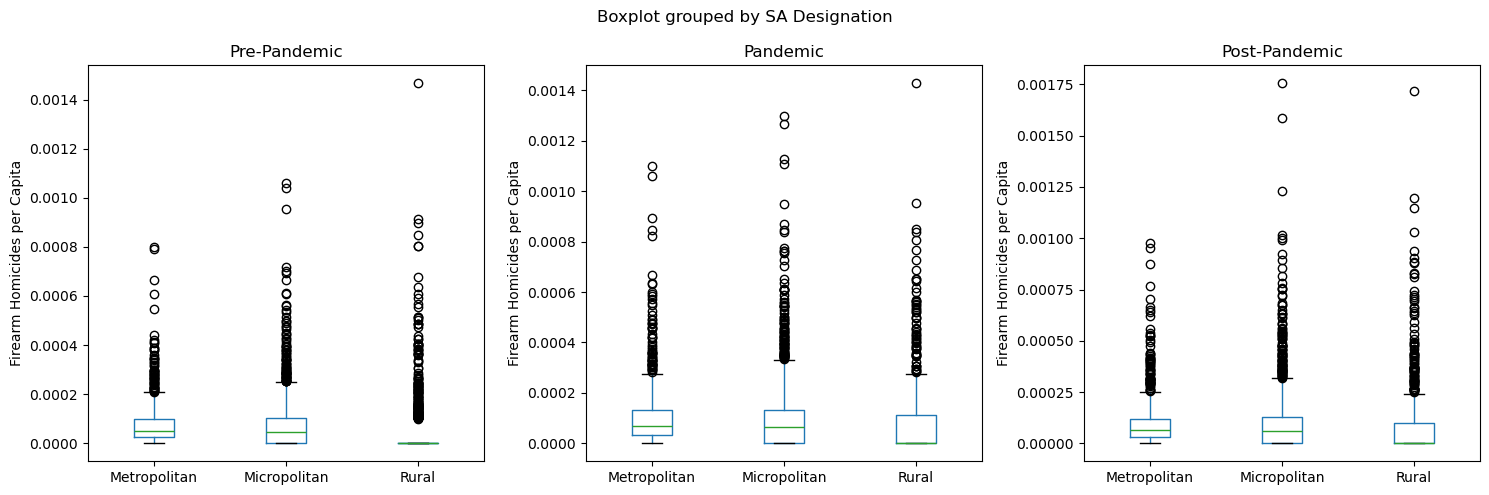

                              sum_sq      df          F        PR(>F)
C(Q("SA Designation"))  6.066292e-07     2.0  16.900449  4.715600e-08
C(Period)               1.194473e-06     2.0  33.277545  3.973972e-15
Residual                1.668724e-04  9298.0        NaN           NaN


In [23]:
# compute firearm homicides per capita
county_data["Firearm Homicides per Capita I"] = county_data["Firearm Homicides I"]/county_data["Population I"]
county_data["Firearm Homicides per Capita II"] = county_data["Firearm Homicides II"]/county_data["Population II"]
county_data["Firearm Homicides per Capita III"] = county_data["Firearm Homicides III"]/county_data["Population III"]
county_data["Female Firearm Homicides per Capita I"] = county_data["Female Firearm Homicides I"]/county_data["Population I"]
county_data["Female Firearm Homicides per Capita II"] = county_data["Female Firearm Homicides II"]/county_data["Population II"]
county_data["Female Firearm Homicides per Capita III"] = county_data["Female Firearm Homicides III"]/county_data["Population III"]
county_data["Male Firearm Homicides per Capita I"] = county_data["Male Firearm Homicides I"]/county_data["Population I"]
county_data["Male Firearm Homicides per Capita II"] = county_data["Male Firearm Homicides II"]/county_data["Population II"]
county_data["Male Firearm Homicides per Capita III"] = county_data["Male Firearm Homicides III"]/county_data["Population III"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

county_data.boxplot(column="Firearm Homicides per Capita I", by="SA Designation",showfliers=True,grid=False,ax=axes[0])
axes[0].set_title("Pre-Pandemic")
axes[0].set_xlabel("")
axes[0].set_ylabel("Firearm Homicides per Capita")

county_data.boxplot(column="Firearm Homicides per Capita II", by="SA Designation",showfliers=True,grid=False,ax=axes[1])
axes[1].set_title("Pandemic")
axes[1].set_xlabel("")
axes[1].set_ylabel("Firearm Homicides per Capita")

county_data.boxplot(column="Firearm Homicides per Capita III", by="SA Designation",showfliers=True,grid=False,ax=axes[2])
axes[2].set_title("Post-Pandemic")
axes[2].set_xlabel("")
axes[2].set_ylabel("Firearm Homicides per Capita")

fig.tight_layout()
plt.show()

# Simple ANOVA
anova_data = pd.melt(county_data,id_vars=["SA Designation","County Code"],value_vars=["Firearm Homicides per Capita I","Firearm Homicides per Capita II","Firearm Homicides per Capita III"],
    var_name="Period",value_name="HomicidesPerCapita")

anova_data["Period"] = anova_data["Period"].map({"Firearm Homicides per Capita I": "I","Firearm Homicides per Capita II": "II","Firearm Homicides per Capita III": "III"})

model = ols('HomicidesPerCapita ~ C(Q("SA Designation")) + C(Period)',data=anova_data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


# Perform urban scaling

### Urban scaling of firearm homicides

Pre-pandemic (I)
β = 0.992 ∈ [0.947,1.036]
C = -4.471 ∈ [-4.717,-4.226]
N = 870, n = 773
{'BP_LM_p': 0.047699139778787834, 'BP_F_p': 0.04777677750042807, 'White_LM_p': 0.08863822847366552, 'White_F_p': 0.08879844272998537}
Pandemic (II)
β = 1.053 ∈ [1.009,1.097]
C = -4.694 ∈ [-4.938,-4.45]
N = 870, n = 800
{'BP_LM_p': 0.0031324217831447437, 'BP_F_p': 0.0030973220555290696, 'White_LM_p': 0.011761263189132502, 'White_F_p': 0.01166632718000113}
Post-pandemic (III)
β = 0.928 ∈ [0.904,0.952]
C = -3.385 ∈ [-3.515,-3.254]
N = 870, n = 870
{'BP_LM_p': 0.1597350374571333, 'BP_F_p': 0.1600984910972434, 'White_LM_p': 0.08461208394894056, 'White_F_p': 0.08473935561455007}


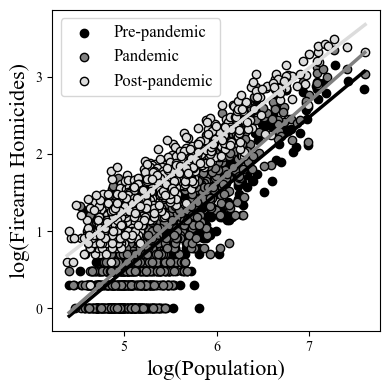

In [103]:
print("Pre-pandemic (I)")
x_title = "Population I"
y_title = "Firearm Homicides I"
[samis_I, b_I, b_min_I, b_upperbound_I, c_I, c_min_I, c_upperbound_I, N_I, n_I, R2_I, homoscedasticity_results_I] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Firearm Homicides SAMIs I"] = samis_I.reindex(list(range(samis_I.index.min(),samis_I.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_I)+" \u2208 ["+str(b_min_I)+","+str(b_upperbound_I)+"]")
print("C = "+str(c_I)+" \u2208 ["+str(c_min_I)+","+str(c_upperbound_I)+"]")
print("N = "+str(N_I)+", n = "+str(n_I))
print(homoscedasticity_results_I)

print("Pandemic (II)")
x_title = "Population II"
y_title = "Firearm Homicides II"
[samis_II, b_II, b_min_II, b_upperbound_II, c_II, c_min_II, c_upperbound_II, N_II, n_II, R2_II, homoscedasticity_results_II] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Firearm Homicides SAMIs II"] = samis_II.reindex(list(range(samis_II.index.min(),samis_II.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_II)+" \u2208 ["+str(b_min_II)+","+str(b_upperbound_II)+"]")
print("C = "+str(c_II)+" \u2208 ["+str(c_min_II)+","+str(c_upperbound_II)+"]")
print("N = "+str(N_II)+", n = "+str(n_II))
print(homoscedasticity_results_II)

print("Post-pandemic (III)")
x_title = "Population III"
y_title = "Firearm Homicides III"
[samis_III, b_III, b_min_III, b_upperbound_III, c_III, c_min_III, c_upperbound_III, N_III, n_III, R2_III, homoscedasticity_results_III] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Firearm Homicides SAMIs III"] = samis_III.reindex(list(range(samis_III.index.min(),samis_III.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_III)+" \u2208 ["+str(b_min_III)+","+str(b_upperbound_III)+"]")
print("C = "+str(c_III)+" \u2208 ["+str(c_min_III)+","+str(c_upperbound_III)+"]")
print("N = "+str(N_III)+", n = "+str(n_III))
print(homoscedasticity_results_III)


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax = plt.subplot(1,1,1)
ax.scatter(np.log10(MSA_data["Population I"]), np.log10(MSA_data["Firearm Homicides I"]), s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pre-pandemic")
ax.scatter(np.log10(MSA_data["Population II"]), np.log10(MSA_data["Firearm Homicides II"]), s=None, c="gray", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pandemic")
ax.scatter(np.log10(MSA_data["Population III"]), np.log10(MSA_data["Firearm Homicides III"]), s=None, c="gainsboro", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Post-pandemic")

for pop_col, b, c, color in [
    ("Population I",   b_I,   c_I,   "black"),
    ("Population II",  b_II,  c_II,  "gray"),
    ("Population III", b_III, c_III, "gainsboro")]:
    x_vals = np.log10(MSA_data[pop_col].replace(0, np.nan).dropna())
    x_fit  = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_fit  = b * x_fit + c
    ax.plot(x_fit, y_fit, color=color, linewidth=2.5, linestyle="-")


ax.set_xlabel("log(Population)", fontfamily="Times New Roman", fontsize=16)
ax.set_ylabel("log(Firearm Homicides)", fontfamily="Times New Roman", fontsize=16)
plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(prop={'family': 'Times New Roman', 'size': 12})

fig.tight_layout()
plt.savefig('Figure1a.pdf')


### Urban scaling of female firearm homicides

Pre-pandemic (I)
β = 0.712 ∈ [0.669,0.755]
C = -3.444 ∈ [-3.678,-3.211]
N = 870, n = 571
{'BP_LM_p': 2.2687513312027258e-05, 'BP_F_p': 2.0335519535420138e-05, 'White_LM_p': 0.0001075468512419662, 'White_F_p': 9.725110679547083e-05}
Pandemic (II)
β = 0.806 ∈ [0.763,0.848]
C = -3.893 ∈ [-4.125,-3.661]
N = 870, n = 603
{'BP_LM_p': 0.0064258559520545475, 'BP_F_p': 0.006372015731198576, 'White_LM_p': 0.007764280172274402, 'White_F_p': 0.007647155532784968}
Post-pandemic (III)
β = 0.895 ∈ [0.864,0.926]
C = -3.989 ∈ [-4.16,-3.817]
N = 870, n = 810
{'BP_LM_p': 0.001163481931675611, 'BP_F_p': 0.0011407240672599793, 'White_LM_p': 0.00212478033802648, 'White_F_p': 0.002073837273455055}


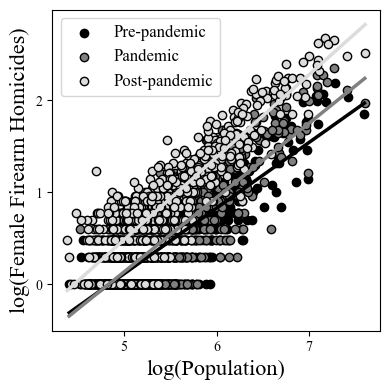

In [28]:
print("Pre-pandemic (I)")
x_title = "Population I"
y_title = "Female Firearm Homicides I"
[samis_I, b_I, b_min_I, b_upperbound_I, c_I, c_min_I, c_upperbound_I, N_I, n_I, R2_I, homoscedasticity_results_I] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Female Firearm Homicides SAMIs I"] = samis_I.reindex(list(range(samis_I.index.min(),samis_I.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_I)+" \u2208 ["+str(b_min_I)+","+str(b_upperbound_I)+"]")
print("C = "+str(c_I)+" \u2208 ["+str(c_min_I)+","+str(c_upperbound_I)+"]")
print("N = "+str(N_I)+", n = "+str(n_I))
print(homoscedasticity_results_I)

print("Pandemic (II)")
x_title = "Population II"
y_title = "Female Firearm Homicides II"
[samis_II, b_II, b_min_II, b_upperbound_II, c_II, c_min_II, c_upperbound_II, N_II, n_II, R2_II, homoscedasticity_results_II] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Female Firearm Homicides SAMIs II"] = samis_II.reindex(list(range(samis_II.index.min(),samis_II.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_II)+" \u2208 ["+str(b_min_II)+","+str(b_upperbound_II)+"]")
print("C = "+str(c_II)+" \u2208 ["+str(c_min_II)+","+str(c_upperbound_II)+"]")
print("N = "+str(N_II)+", n = "+str(n_II))
print(homoscedasticity_results_II)

print("Post-pandemic (III)")
x_title = "Population III"
y_title = "Female Firearm Homicides III"
[samis_III, b_III, b_min_III, b_upperbound_III, c_III, c_min_III, c_upperbound_III, N_III, n_III, R2_III, homoscedasticity_results_III] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Female Firearm Homicides SAMIs III"] = samis_III.reindex(list(range(samis_III.index.min(),samis_III.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_III)+" \u2208 ["+str(b_min_III)+","+str(b_upperbound_III)+"]")
print("C = "+str(c_III)+" \u2208 ["+str(c_min_III)+","+str(c_upperbound_III)+"]")
print("N = "+str(N_III)+", n = "+str(n_III))
print(homoscedasticity_results_III)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax = plt.subplot(1,1,1)
ax.scatter(np.log10(MSA_data["Population I"]), np.log10(MSA_data["Female Firearm Homicides I"]), s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pre-pandemic")
ax.scatter(np.log10(MSA_data["Population II"]), np.log10(MSA_data["Female Firearm Homicides II"]), s=None, c="gray", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pandemic")
ax.scatter(np.log10(MSA_data["Population III"]), np.log10(MSA_data["Female Firearm Homicides III"]), s=None, c="gainsboro", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Post-pandemic")

for pop_col, b, c, color in [
    ("Population I",   b_I,   c_I,   "black"),
    ("Population II",  b_II,  c_II,  "gray"),
    ("Population III", b_III, c_III, "gainsboro")]:
    x_vals = np.log10(MSA_data[pop_col].replace(0, np.nan).dropna())
    x_fit  = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_fit  = b * x_fit + c
    ax.plot(x_fit, y_fit, color=color, linewidth=2.5, linestyle="-")

ax.set_xlabel("log(Population)", fontfamily="Times New Roman", fontsize=16)
ax.set_ylabel("log(Female Firearm Homicides)", fontfamily="Times New Roman", fontsize=16)
plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(prop={'family': 'Times New Roman', 'size': 12})

fig.tight_layout()
plt.savefig('Figure1b.pdf')


### Urban scaling of male firearm homicides

Pre-pandemic (I)
β = 0.976 ∈ [0.929,1.023]
C = -4.464 ∈ [-4.722,-4.207]
N = 870, n = 723
{'BP_LM_p': 0.388120691072285, 'BP_F_p': 0.38882000857193355, 'White_LM_p': 0.2644108424088084, 'White_F_p': 0.26522551216973317}
Pandemic (II)
β = 1.032 ∈ [0.985,1.079]
C = -4.663 ∈ [-4.921,-4.405]
N = 870, n = 767
{'BP_LM_p': 0.053989098326630014, 'BP_F_p': 0.05408989832579896, 'White_LM_p': 0.09146972158375383, 'White_F_p': 0.09164320836570287}
Post-pandemic (III)
β = 0.931 ∈ [0.907,0.955]
C = -3.476 ∈ [-3.607,-3.345]
N = 870, n = 870
{'BP_LM_p': 0.09072370978943493, 'BP_F_p': 0.09092241199091965, 'White_LM_p': 0.026082571571207462, 'White_F_p': 0.026011134944558388}


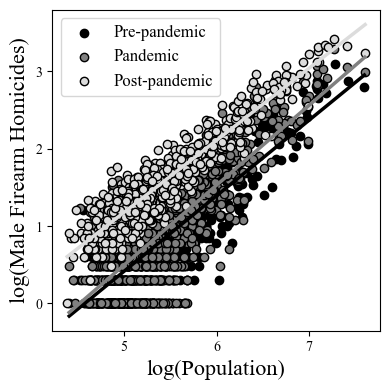

In [30]:
print("Pre-pandemic (I)")
x_title = "Population I"
y_title = "Male Firearm Homicides I"
[samis_I, b_I, b_min_I, b_upperbound_I, c_I, c_min_I, c_upperbound_I, N_I, n_I, R2_I, homoscedasticity_results_I] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Male Firearm Homicides SAMIs I"] = samis_I.reindex(list(range(samis_I.index.min(),samis_I.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_I)+" \u2208 ["+str(b_min_I)+","+str(b_upperbound_I)+"]")
print("C = "+str(c_I)+" \u2208 ["+str(c_min_I)+","+str(c_upperbound_I)+"]")
print("N = "+str(N_I)+", n = "+str(n_I))
print(homoscedasticity_results_I)

print("Pandemic (II)")
x_title = "Population II"
y_title = "Male Firearm Homicides II"
[samis_II, b_II, b_min_II, b_upperbound_II, c_II, c_min_II, c_upperbound_II, N_II, n_II, R2_II, homoscedasticity_results_II] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Male Firearm Homicides SAMIs II"] = samis_II.reindex(list(range(samis_II.index.min(),samis_II.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_II)+" \u2208 ["+str(b_min_II)+","+str(b_upperbound_II)+"]")
print("C = "+str(c_II)+" \u2208 ["+str(c_min_II)+","+str(c_upperbound_II)+"]")
print("N = "+str(N_II)+", n = "+str(n_II))
print(homoscedasticity_results_II)

print("Post-pandemic (III)")
x_title = "Population III"
y_title = "Male Firearm Homicides III"
[samis_III, b_III, b_min_III, b_upperbound_III, c_III, c_min_III, c_upperbound_III, N_III, n_III, R2_III, homoscedasticity_results_III] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Male Firearm Homicides SAMIs III"] = samis_III.reindex(list(range(samis_III.index.min(),samis_III.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_III)+" \u2208 ["+str(b_min_III)+","+str(b_upperbound_III)+"]")
print("C = "+str(c_III)+" \u2208 ["+str(c_min_III)+","+str(c_upperbound_III)+"]")
print("N = "+str(N_III)+", n = "+str(n_III))
print(homoscedasticity_results_III)


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax = plt.subplot(1,1,1)
ax.scatter(np.log10(MSA_data["Population I"]), np.log10(MSA_data["Male Firearm Homicides I"]), s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pre-pandemic")
ax.scatter(np.log10(MSA_data["Population II"]), np.log10(MSA_data["Male Firearm Homicides II"]), s=None, c="gray", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pandemic")
ax.scatter(np.log10(MSA_data["Population III"]), np.log10(MSA_data["Male Firearm Homicides III"]), s=None, c="gainsboro", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Post-pandemic")

for pop_col, b, c, color in [
    ("Population I",   b_I,   c_I,   "black"),
    ("Population II",  b_II,  c_II,  "gray"),
    ("Population III", b_III, c_III, "gainsboro")]:
    x_vals = np.log10(MSA_data[pop_col].replace(0, np.nan).dropna())
    x_fit  = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_fit  = b * x_fit + c
    ax.plot(x_fit, y_fit, color=color, linewidth=2.5, linestyle="-")

ax.set_xlabel("log(Population)", fontfamily="Times New Roman", fontsize=16)
ax.set_ylabel("log(Male Firearm Homicides)", fontfamily="Times New Roman", fontsize=16)
plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(prop={'family': 'Times New Roman', 'size': 12})

fig.tight_layout()
plt.savefig('Figure1c.pdf')


### Scaling of firearm ownership

Pre-pandemic (I)
β = 0.947 ∈ [0.931,0.964]
C = 0.015 ∈ [-0.074,0.104]
N = 870, n = 869
{'BP_LM_p': 0.05978092753428127, 'BP_F_p': 0.05988804000255162, 'White_LM_p': 0.00016609579869788572, 'White_F_p': 0.00015673769214570238}
Pandemic (II)
β = 0.956 ∈ [0.94,0.972]
C = -0.014 ∈ [-0.102,0.075]
N = 870, n = 869
{'BP_LM_p': 0.09264919540328015, 'BP_F_p': 0.09285349489675296, 'White_LM_p': 0.001621207121626291, 'White_F_p': 0.001580189761066361}
Post-pandemic (III)
β = 1.018 ∈ [1.004,1.033]
C = 0.019 ∈ [-0.062,0.1]
N = 870, n = 870
{'BP_LM_p': 4.653842548591962e-05, 'BP_F_p': 4.386988372383881e-05, 'White_LM_p': 3.655438730130359e-07, 'White_F_p': 2.9737248079243486e-07}


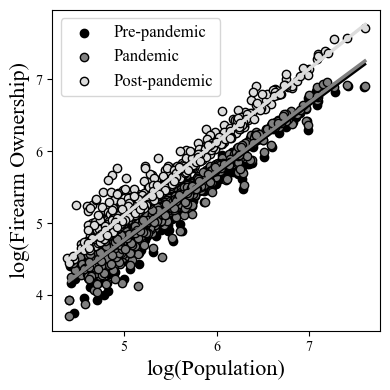

In [32]:
print("Pre-pandemic (I)")
x_title = "Population I"
y_title = "Firearm Ownership I"
[samis_I, b_I, b_min_I, b_upperbound_I, c_I, c_min_I, c_upperbound_I, N_I, n_I, R2_I, homoscedasticity_results_I] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Firearm Ownership SAMIs I"] = samis_I.reindex(list(range(samis_I.index.min(),samis_I.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_I)+" \u2208 ["+str(b_min_I)+","+str(b_upperbound_I)+"]")
print("C = "+str(c_I)+" \u2208 ["+str(c_min_I)+","+str(c_upperbound_I)+"]")
print("N = "+str(N_I)+", n = "+str(n_I))
print(homoscedasticity_results_I)

print("Pandemic (II)")
x_title = "Population II"
y_title = "Firearm Ownership II"
[samis_II, b_II, b_min_II, b_upperbound_II, c_II, c_min_II, c_upperbound_II, N_II, n_II, R2_II, homoscedasticity_results_II]  = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Firearm Ownership SAMIs II"] = samis_II.reindex(list(range(samis_II.index.min(),samis_II.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_II)+" \u2208 ["+str(b_min_II)+","+str(b_upperbound_II)+"]")
print("C = "+str(c_II)+" \u2208 ["+str(c_min_II)+","+str(c_upperbound_II)+"]")
print("N = "+str(N_II)+", n = "+str(n_II))
print(homoscedasticity_results_II)

print("Post-pandemic (III)")
x_title = "Population III"
y_title = "Firearm Ownership III"
[samis_III, b_III, b_min_III, b_upperbound_III, c_III, c_min_III, c_upperbound_III, N_III, n_III, R2_III, homoscedasticity_results_III] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Firearm Ownership SAMIs III"] = samis_III.reindex(list(range(samis_III.index.min(),samis_III.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_III)+" \u2208 ["+str(b_min_III)+","+str(b_upperbound_III)+"]")
print("C = "+str(c_III)+" \u2208 ["+str(c_min_III)+","+str(c_upperbound_III)+"]")
print("N = "+str(N_III)+", n = "+str(n_III))
print(homoscedasticity_results_III)


fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax = plt.subplot(1,1,1)
ax.scatter(np.log10(MSA_data["Population I"]), np.log10(MSA_data["Firearm Ownership I"]), s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pre-pandemic")
ax.scatter(np.log10(MSA_data["Population II"]), np.log10(MSA_data["Firearm Ownership II"]), s=None, c="gray", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pandemic")
ax.scatter(np.log10(MSA_data["Population III"]), np.log10(MSA_data["Firearm Ownership III"]), s=None, c="gainsboro", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Post-pandemic")

for pop_col, b, c, color in [
    ("Population I",   b_I,   c_I,   "black"),
    ("Population II",  b_II,  c_II,  "gray"),
    ("Population III", b_III, c_III, "gainsboro")]:
    x_vals = np.log10(MSA_data[pop_col].replace(0, np.nan).dropna())
    x_fit  = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_fit  = b * x_fit + c
    ax.plot(x_fit, y_fit, color=color, linewidth=2.5, linestyle="-")

ax.set_xlabel("log(Population)", fontfamily="Times New Roman", fontsize=16)
ax.set_ylabel("log(Firearm Ownership)", fontfamily="Times New Roman", fontsize=16)
plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(prop={'family': 'Times New Roman', 'size': 12})

fig.tight_layout()
plt.savefig('eFigure1a.pdf')


### Scaling of licensed firearm dealerships

Pre-pandemic (I)
β = 0.698 ∈ [0.67,0.725]
C = -2.113 ∈ [-2.258,-1.968]
N = 870, n = 870
{'BP_LM_p': 0.019932077428384952, 'BP_F_p': 0.019916954111356414, 'White_LM_p': 0.049914716256246175, 'White_F_p': 0.04991456203088208}
Pandemic (II)
β = 0.701 ∈ [0.673,0.729]
C = -2.138 ∈ [-2.288,-1.988]
N = 870, n = 870
{'BP_LM_p': 0.040707971342667945, 'BP_F_p': 0.040754804066617606, 'White_LM_p': 0.03307952393552309, 'White_F_p': 0.03302578644075215}
Post-pandemic (III)
β = 0.707 ∈ [0.678,0.736]
C = -2.167 ∈ [-2.321,-2.012]
N = 870, n = 870
{'BP_LM_p': 0.10449084255890517, 'BP_F_p': 0.10472691817748732, 'White_LM_p': 0.03443700076999056, 'White_F_p': 0.034387109324861796}


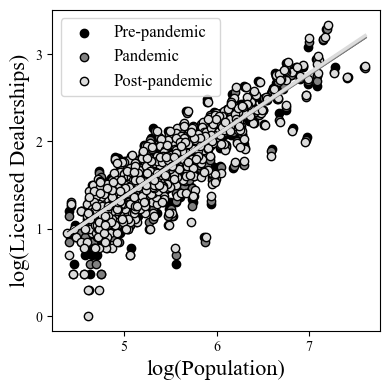

In [34]:
print("Pre-pandemic (I)")
x_title = "Population I"
y_title = "Licensed Dealerships I"
[samis_I, b_I, b_min_I, b_upperbound_I, c_I, c_min_I, c_upperbound_I, N_I, n_I, R2_I, homoscedasticity_results_I] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Licensed Dealerships SAMIs I"]  = samis_I.reindex(list(range(samis_I.index.min(),samis_I.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_I)+" \u2208 ["+str(b_min_I)+","+str(b_upperbound_I)+"]")
print("C = "+str(c_I)+" \u2208 ["+str(c_min_I)+","+str(c_upperbound_I)+"]")
print("N = "+str(N_I)+", n = "+str(n_I))
print(homoscedasticity_results_I)

print("Pandemic (II)")
x_title = "Population II"
y_title = "Licensed Dealerships II"
[samis_II, b_II, b_min_II, b_upperbound_II, c_II, c_min_II, c_upperbound_II, N_II, n_II, R2_II, homoscedasticity_results_II]  = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Licensed Dealerships SAMIs II"] = samis_II.reindex(list(range(samis_II.index.min(),samis_II.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_II)+" \u2208 ["+str(b_min_II)+","+str(b_upperbound_II)+"]")
print("C = "+str(c_II)+" \u2208 ["+str(c_min_II)+","+str(c_upperbound_II)+"]")
print("N = "+str(N_II)+", n = "+str(n_II))
print(homoscedasticity_results_II)

print("Post-pandemic (III)")
x_title = "Population III"
y_title = "Licensed Dealerships III"
[samis_III, b_III, b_min_III, b_upperbound_III, c_III, c_min_III, c_upperbound_III, N_III, n_III, R2_III, homoscedasticity_results_III] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Licensed Dealerships SAMIs III"] = samis_III.reindex(list(range(samis_III.index.min(),samis_III.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b_III)+" \u2208 ["+str(b_min_III)+","+str(b_upperbound_III)+"]")
print("C = "+str(c_III)+" \u2208 ["+str(c_min_III)+","+str(c_upperbound_III)+"]")
print("N = "+str(N_III)+", n = "+str(n_III))
print(homoscedasticity_results_III)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax = plt.subplot(1,1,1)
ax.scatter(np.log10(MSA_data["Population I"]), np.log10(MSA_data["Licensed Dealerships I"]), s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pre-pandemic")
ax.scatter(np.log10(MSA_data["Population II"]), np.log10(MSA_data["Licensed Dealerships II"]), s=None, c="gray", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Pandemic")
ax.scatter(np.log10(MSA_data["Population III"]), np.log10(MSA_data["Licensed Dealerships III"]), s=None, c="gainsboro", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Post-pandemic")

for pop_col, b, c, color in [
    ("Population I",   b_I,   c_I,   "black"),
    ("Population II",  b_II,  c_II,  "gray"),
    ("Population III", b_III, c_III, "gainsboro")]:
    x_vals = np.log10(MSA_data[pop_col].replace(0, np.nan).dropna())
    x_fit  = np.linspace(x_vals.min(), x_vals.max(), 200)
    y_fit  = b * x_fit + c
    ax.plot(x_fit, y_fit, color=color, linewidth=2.5, linestyle="-")

ax.set_xlabel("log(Population)", fontfamily="Times New Roman", fontsize=16)
ax.set_ylabel("log(Licensed Dealerships)", fontfamily="Times New Roman", fontsize=16)
plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(prop={'family': 'Times New Roman', 'size': 12})

fig.tight_layout()
plt.savefig('eFigure1b.pdf')


### Scaling of domestic violence shelters

Post-pandemic (III)
β = 0.484 ∈ [0.446,0.521]
C = -2.406 ∈ [-2.605,-2.207]
N = 870, n = 721
{'BP_LM_p': 6.580698980483419e-22, 'BP_F_p': 2.931078775515076e-23, 'White_LM_p': 1.847329388958871e-24, 'White_F_p': 2.3411025963673828e-26}


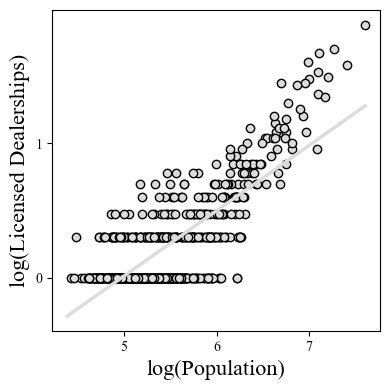

In [36]:
print("Post-pandemic (III)")
x_title = "Population III"
y_title = "Domestic Violence Shelters III"
[samis, b, b_min, b_upperbound, c, c_min, c_upperbound, N, n, R2, homoscedasticity_results] = perform_scaling(MSA_data,x_title,y_title,"no plot")
MSA_data["Domestic Violence Shelters SAMIs III"] = samis.reindex(list(range(samis.index.min(),samis.index.max()+1)),fill_value='NaN')
print("\u03B2 = "+str(b)+" \u2208 ["+str(b_min)+","+str(b_upperbound)+"]")
print("C = "+str(c)+" \u2208 ["+str(c_min)+","+str(c_upperbound)+"]")
print("N = "+str(N)+", n = "+str(n))
print(homoscedasticity_results)

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax = plt.subplot(1,1,1)
ax.scatter(np.log10(MSA_data["Population III"]), np.log10(MSA_data["Domestic Violence Shelters III"]), s=None, c="gainsboro", marker=None, alpha=None, linewidths=None, edgecolors="black", label="Post-pandemic")

x_vals = np.log10(MSA_data["Population III"].replace(0, np.nan).dropna())
x_fit  = np.linspace(x_vals.min(), x_vals.max(), 200)
y_fit  = b * x_fit + c
ax.plot(x_fit, y_fit, color=color, linewidth=2.5, linestyle="-")

ax.set_xlabel("log(Population)", fontfamily="Times New Roman", fontsize=16)
ax.set_ylabel("log(Licensed Dealerships)", fontfamily="Times New Roman", fontsize=16)
plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()
plt.savefig('eFigure1c.pdf')


# Inspect differences in SAMIs

In [38]:
# make sure SAMIs are numeric (there are some N/As)
MSA_data["Firearm Homicides SAMIs I"] = pd.to_numeric(MSA_data["Firearm Homicides SAMIs I"],errors="coerce")
MSA_data["Firearm Homicides SAMIs II"] = pd.to_numeric(MSA_data["Firearm Homicides SAMIs II"],errors="coerce")
MSA_data["Firearm Homicides SAMIs III"] = pd.to_numeric(MSA_data["Firearm Homicides SAMIs III"],errors="coerce")
MSA_data["Male Firearm Homicides SAMIs I"] = pd.to_numeric(MSA_data["Male Firearm Homicides SAMIs I"],errors="coerce")
MSA_data["Male Firearm Homicides SAMIs II"] = pd.to_numeric(MSA_data["Male Firearm Homicides SAMIs II"],errors="coerce")
MSA_data["Male Firearm Homicides SAMIs III"] = pd.to_numeric(MSA_data["Male Firearm Homicides SAMIs III"],errors="coerce")
MSA_data["Female Firearm Homicides SAMIs I"] = pd.to_numeric(MSA_data["Female Firearm Homicides SAMIs I"],errors="coerce")
MSA_data["Female Firearm Homicides SAMIs II"] = pd.to_numeric(MSA_data["Female Firearm Homicides SAMIs II"],errors="coerce")
MSA_data["Female Firearm Homicides SAMIs III"] = pd.to_numeric(MSA_data["Female Firearm Homicides SAMIs III"],errors="coerce")
MSA_data["Firearm Ownership SAMIs I"] = pd.to_numeric(MSA_data["Firearm Ownership SAMIs I"],errors="coerce")
MSA_data["Firearm Ownership SAMIs II"] = pd.to_numeric(MSA_data["Firearm Ownership SAMIs II"],errors="coerce")
MSA_data["Firearm Ownership SAMIs III"] = pd.to_numeric(MSA_data["Firearm Ownership SAMIs III"],errors="coerce")

# compute SAMI ranks
MSA_data["Firearm Homicides SAMI Ranks I"] = (MSA_data["Firearm Homicides SAMIs I"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Firearm Homicides SAMI Ranks II"] = (MSA_data["Firearm Homicides SAMIs II"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Firearm Homicides SAMI Ranks III"] = (MSA_data["Firearm Homicides SAMIs III"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Male Firearm Homicides SAMI Ranks I"] = (MSA_data["Male Firearm Homicides SAMIs I"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Male Firearm Homicides SAMI Ranks II"] = (MSA_data["Male Firearm Homicides SAMIs II"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Male Firearm Homicides SAMI Ranks III"] = (MSA_data["Male Firearm Homicides SAMIs III"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Female Firearm Homicides SAMI Ranks I"] = (MSA_data["Female Firearm Homicides SAMIs I"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Female Firearm Homicides SAMI Ranks II"] = (MSA_data["Female Firearm Homicides SAMIs II"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Female Firearm Homicides SAMI Ranks III"] = (MSA_data["Female Firearm Homicides SAMIs III"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Firearm Ownership SAMI Ranks I"] = (MSA_data["Firearm Ownership SAMIs I"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Firearm Ownership SAMI Ranks II"] = (MSA_data["Firearm Ownership SAMIs II"].rank(ascending=False, method="min").astype("Int64"))
MSA_data["Firearm Ownership SAMI Ranks III"] = (MSA_data["Firearm Ownership SAMIs III"].rank(ascending=False, method="min").astype("Int64"))

# compute differences in SAMI ranks between time periods
MSA_data["Firearm Homicides SAMI Ranks II-I"] = MSA_data["Firearm Homicides SAMI Ranks II"] - MSA_data["Firearm Homicides SAMI Ranks I"]
MSA_data["Firearm Homicides SAMI Ranks III-II"] = MSA_data["Firearm Homicides SAMI Ranks III"] - MSA_data["Firearm Homicides SAMI Ranks II"]
MSA_data["Firearm Homicides SAMI Ranks III-I"] = MSA_data["Firearm Homicides SAMI Ranks III"] - MSA_data["Firearm Homicides SAMI Ranks I"]
MSA_data["Male Firearm Homicides SAMI Ranks II-I"] = MSA_data["Male Firearm Homicides SAMI Ranks II"] - MSA_data["Male Firearm Homicides SAMI Ranks I"]
MSA_data["Male Firearm Homicides SAMI Ranks III-II"] = MSA_data["Male Firearm Homicides SAMI Ranks III"] - MSA_data["Male Firearm Homicides SAMI Ranks II"]
MSA_data["Male Firearm Homicides SAMI Ranks III-I"] = MSA_data["Male Firearm Homicides SAMI Ranks III"] - MSA_data["Male Firearm Homicides SAMI Ranks I"]
MSA_data["Female Firearm Homicides SAMI Ranks II-I"] = MSA_data["Female Firearm Homicides SAMI Ranks II"] - MSA_data["Female Firearm Homicides SAMI Ranks I"]
MSA_data["Female Firearm Homicides SAMI Ranks III-II"] = MSA_data["Female Firearm Homicides SAMI Ranks III"] - MSA_data["Female Firearm Homicides SAMI Ranks II"]
MSA_data["Female Firearm Homicides SAMI Ranks III-I"] = MSA_data["Female Firearm Homicides SAMI Ranks III"] - MSA_data["Female Firearm Homicides SAMI Ranks I"]
MSA_data["Firearm Ownership SAMI Ranks II-I"] = MSA_data["Firearm Ownership SAMI Ranks II"] - MSA_data["Firearm Ownership SAMI Ranks I"]
MSA_data["Firearm Ownership SAMI Ranks III-II"] = MSA_data["Firearm Ownership SAMI Ranks III"] - MSA_data["Firearm Ownership SAMI Ranks II"]
MSA_data["Firearm Ownership SAMI Ranks III-I"] = MSA_data["Firearm Ownership SAMI Ranks III"] - MSA_data["Firearm Ownership SAMI Ranks I"]


## SAMI analysis for firearm homicides

### Pre-pandemic (I) and Pandemic (II)

                                OLS Regression Results                                
Dep. Variable:     Firearm Homicides SAMIs II   R-squared:                       0.604
Model:                                    OLS   Adj. R-squared:                  0.604
Method:                         Least Squares   F-statistic:                     1104.
Date:                        Mon, 13 Jul 2026   Prob (F-statistic):          1.13e-147
Time:                                12:25:04   Log-Likelihood:                -3.2988
No. Observations:                         725   AIC:                             10.60
Df Residuals:                             723   BIC:                             19.77
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

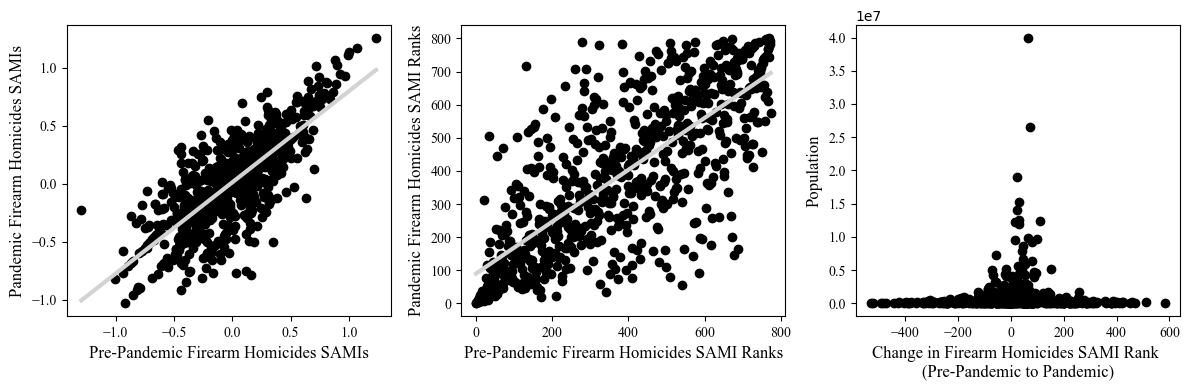

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# SAMI values
x = MSA_data["Firearm Homicides SAMIs I"]
y = MSA_data["Firearm Homicides SAMIs II"]
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x.iloc[:, 1], y) 
print(f"SAMI Values: Pearson's r = {r:.3f}, p = {p:.3e}")


ax = plt.subplot(1,3,1)
ax.scatter(MSA_data[["Firearm Homicides SAMIs I"]], MSA_data[["Firearm Homicides SAMIs II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pre-Pandemic Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Pandemic Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

# SAMI Ranks
x = pd.to_numeric(MSA_data["Firearm Homicides SAMI Ranks I"], errors="coerce")
y = pd.to_numeric(MSA_data["Firearm Homicides SAMI Ranks II"], errors="coerce")
x = x.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x[:, 1], y)
print(f"SAMI Ranks: Pearson's r = {r:.3f}, p = {p:.3e}")

ax = plt.subplot(1,3,2)
ax.scatter(MSA_data[["Firearm Homicides SAMI Ranks I"]], MSA_data[["Firearm Homicides SAMI Ranks II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pre-Pandemic Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Pandemic Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

ax = plt.subplot(1,3,3)
ax.scatter(MSA_data[["Firearm Homicides SAMI Ranks II-I"]], MSA_data[["Population I"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Change in Firearm Homicides SAMI Rank \n(Pre-Pandemic to Pandemic)", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Population", fontfamily="Times New Roman", fontsize=12)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

fig.tight_layout()
plt.savefig('Figure2abc.pdf')
plt.show()


### Pandemic (II) and Post-Pandemic (II)

                                 OLS Regression Results                                
Dep. Variable:     Firearm Homicides SAMIs III   R-squared:                       0.384
Model:                                     OLS   Adj. R-squared:                  0.383
Method:                          Least Squares   F-statistic:                     496.8
Date:                         Mon, 13 Jul 2026   Prob (F-statistic):           6.12e-86
Time:                                 12:25:04   Log-Likelihood:                 368.76
No. Observations:                          800   AIC:                            -733.5
Df Residuals:                              798   BIC:                            -724.1
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

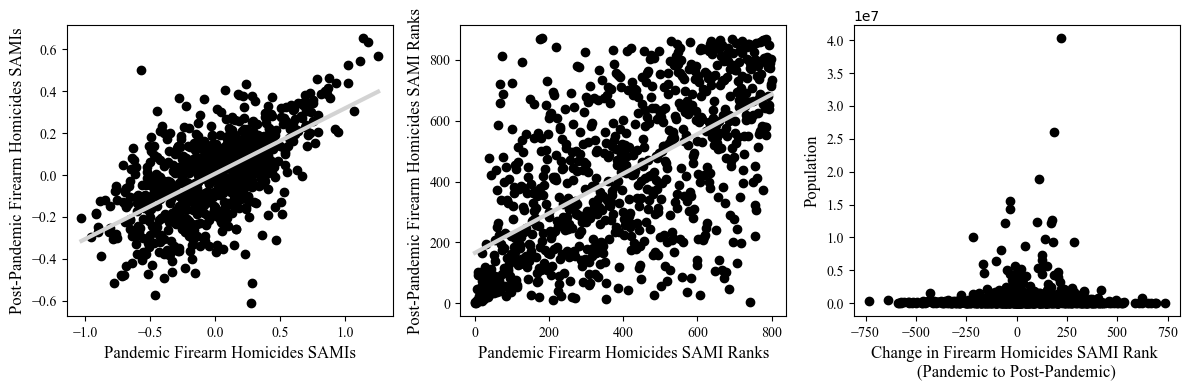

In [43]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# SAMI values
x = MSA_data["Firearm Homicides SAMIs II"]
y = MSA_data["Firearm Homicides SAMIs III"]
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x.iloc[:, 1], y) 
print(f"SAMI Values: Pearson's r = {r:.3f}, p = {p:.3e}")


ax = plt.subplot(1,3,1)
ax.scatter(MSA_data[["Firearm Homicides SAMIs II"]], MSA_data[["Firearm Homicides SAMIs III"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pandemic Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Post-Pandemic Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

# SAMI Ranks

x = pd.to_numeric(MSA_data["Firearm Homicides SAMI Ranks II"], errors="coerce")
y = pd.to_numeric(MSA_data["Firearm Homicides SAMI Ranks III"], errors="coerce")
x = x.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x[:, 1], y)
print(f"SAMI Ranks: Pearson's r = {r:.3f}, p = {p:.3e}")

ax = plt.subplot(1,3,2)
ax.scatter(MSA_data[["Firearm Homicides SAMI Ranks II"]], MSA_data[["Firearm Homicides SAMI Ranks III"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pandemic Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Post-Pandemic Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

ax = plt.subplot(1,3,3)
ax.scatter(MSA_data[["Firearm Homicides SAMI Ranks III-II"]], MSA_data[["Population II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Change in Firearm Homicides SAMI Rank \n(Pandemic to Post-Pandemic)", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Population", fontfamily="Times New Roman", fontsize=12)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

fig.tight_layout()
plt.savefig('Figure2def.pdf')
plt.show()


## SAMI analysis for female firearm homicides

### Pre-pandemic (I) and Pandemic (II)

                                    OLS Regression Results                                   
Dep. Variable:     Female Firearm Homicides SAMIs II   R-squared:                       0.273
Model:                                           OLS   Adj. R-squared:                  0.271
Method:                                Least Squares   F-statistic:                     169.4
Date:                               Mon, 13 Jul 2026   Prob (F-statistic):           4.15e-33
Time:                                       12:25:05   Log-Likelihood:                -40.773
No. Observations:                                454   AIC:                             85.55
Df Residuals:                                    452   BIC:                             93.78
Df Model:                                          1                                         
Covariance Type:                           nonrobust                                         
                                       coef    std err      

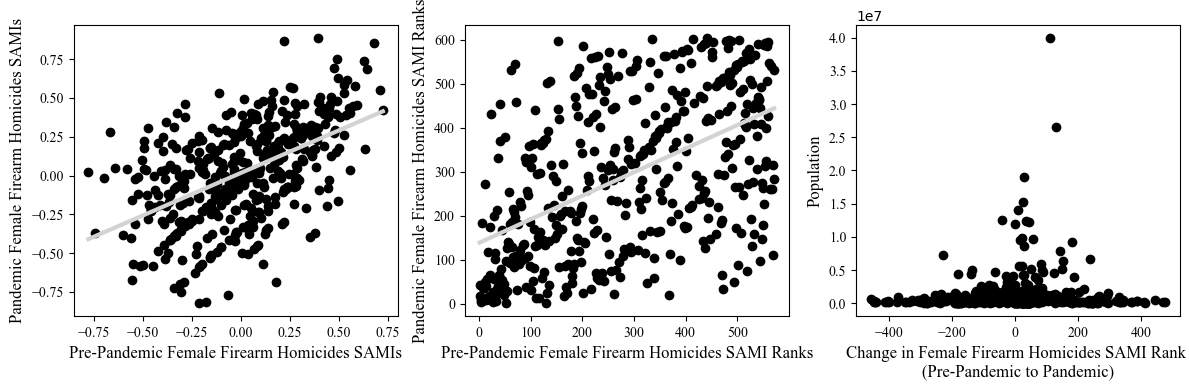

In [46]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# SAMI values
x = MSA_data["Female Firearm Homicides SAMIs I"]
y = MSA_data["Female Firearm Homicides SAMIs II"]
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x.iloc[:, 1], y) 
print(f"SAMI Values: Pearson's r = {r:.3f}, p = {p:.3e}")


ax = plt.subplot(1,3,1)
ax.scatter(MSA_data[["Female Firearm Homicides SAMIs I"]], MSA_data[["Female Firearm Homicides SAMIs II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pre-Pandemic Female Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Pandemic Female Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

# SAMI Ranks
x = pd.to_numeric(MSA_data["Female Firearm Homicides SAMI Ranks I"], errors="coerce")
y = pd.to_numeric(MSA_data["Female Firearm Homicides SAMI Ranks II"], errors="coerce")
x = x.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x[:, 1], y)
print(f"SAMI Ranks: Pearson's r = {r:.3f}, p = {p:.3e}")

ax = plt.subplot(1,3,2)
ax.scatter(MSA_data[["Female Firearm Homicides SAMI Ranks I"]], MSA_data[["Female Firearm Homicides SAMI Ranks II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pre-Pandemic Female Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Pandemic Female Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

ax = plt.subplot(1,3,3)
ax.scatter(MSA_data[["Female Firearm Homicides SAMI Ranks II-I"]], MSA_data[["Population I"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Change in Female Firearm Homicides SAMI Rank \n(Pre-Pandemic to Pandemic)", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Population", fontfamily="Times New Roman", fontsize=12)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

fig.tight_layout()
plt.savefig('eFigure2abc.pdf')
plt.show()


### Pandemic (II) and Post-pandemic (III)

                                    OLS Regression Results                                    
Dep. Variable:     Female Firearm Homicides SAMIs III   R-squared:                       0.178
Model:                                            OLS   Adj. R-squared:                  0.176
Method:                                 Least Squares   F-statistic:                     126.2
Date:                                Mon, 13 Jul 2026   Prob (F-statistic):           1.18e-26
Time:                                        12:25:05   Log-Likelihood:                 38.883
No. Observations:                                 586   AIC:                            -73.77
Df Residuals:                                     584   BIC:                            -65.02
Df Model:                                           1                                         
Covariance Type:                            nonrobust                                         
                                        coef    st

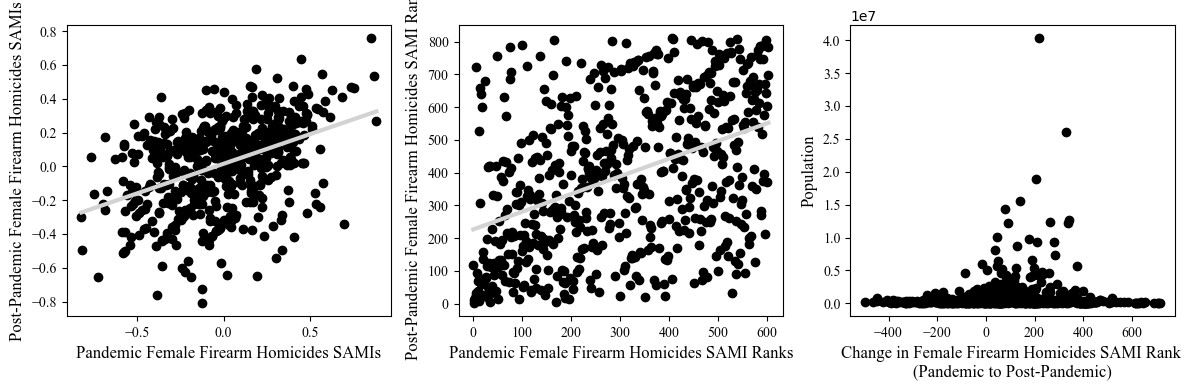

In [48]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# SAMI values
x = MSA_data["Female Firearm Homicides SAMIs II"]
y = MSA_data["Female Firearm Homicides SAMIs III"]
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x.iloc[:, 1], y) 
print(f"SAMI Values: Pearson's r = {r:.3f}, p = {p:.3e}")


ax = plt.subplot(1,3,1)
ax.scatter(MSA_data[["Female Firearm Homicides SAMIs II"]], MSA_data[["Female Firearm Homicides SAMIs III"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pandemic Female Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Post-Pandemic Female Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

# SAMI Ranks

x = pd.to_numeric(MSA_data["Female Firearm Homicides SAMI Ranks II"], errors="coerce")
y = pd.to_numeric(MSA_data["Female Firearm Homicides SAMI Ranks III"], errors="coerce")
x = x.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x[:, 1], y)
print(f"SAMI Ranks: Pearson's r = {r:.3f}, p = {p:.3e}")

ax = plt.subplot(1,3,2)
ax.scatter(MSA_data[["Female Firearm Homicides SAMI Ranks II"]], MSA_data[["Female Firearm Homicides SAMI Ranks III"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pandemic Female Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Post-Pandemic Female Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

ax = plt.subplot(1,3,3)
ax.scatter(MSA_data[["Female Firearm Homicides SAMI Ranks III-II"]], MSA_data[["Population II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Change in Female Firearm Homicides SAMI Rank \n(Pandemic to Post-Pandemic)", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Population", fontfamily="Times New Roman", fontsize=12)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

fig.tight_layout()
plt.savefig('eFigure2def.pdf')
plt.show()


## SAMI analysis for male firearm homicides

### Pre-pandemic (I) and Pandemic (II)

                                   OLS Regression Results                                  
Dep. Variable:     Male Firearm Homicides SAMIs II   R-squared:                       0.613
Model:                                         OLS   Adj. R-squared:                  0.612
Method:                              Least Squares   F-statistic:                     1066.
Date:                             Mon, 13 Jul 2026   Prob (F-statistic):          7.23e-141
Time:                                     12:25:05   Log-Likelihood:                -30.582
No. Observations:                              675   AIC:                             65.16
Df Residuals:                                  673   BIC:                             74.19
Df Model:                                        1                                         
Covariance Type:                         nonrobust                                         
                                     coef    std err          t      P>|t|      

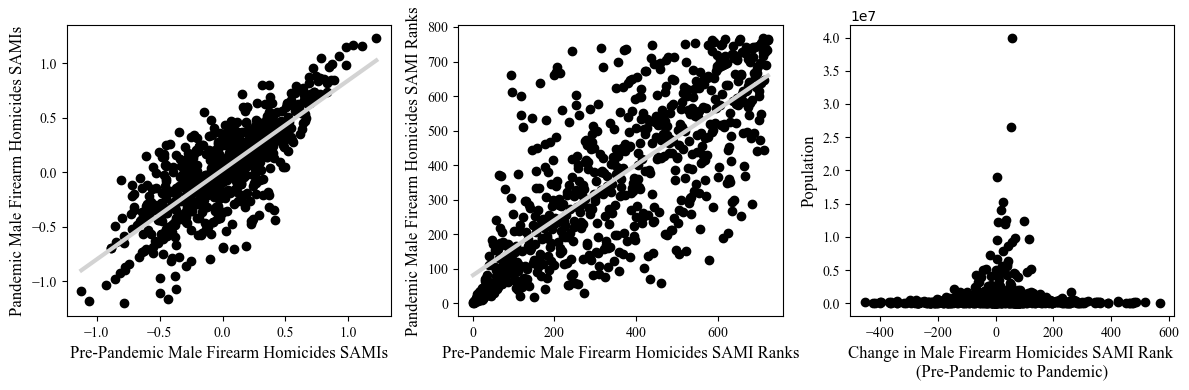

In [51]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# SAMI values
x = MSA_data["Male Firearm Homicides SAMIs I"]
y = MSA_data["Male Firearm Homicides SAMIs II"]
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x.iloc[:, 1], y) 
print(f"SAMI Values: Pearson's r = {r:.3f}, p = {p:.3e}")


ax = plt.subplot(1,3,1)
ax.scatter(MSA_data[["Male Firearm Homicides SAMIs I"]], MSA_data[["Male Firearm Homicides SAMIs II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pre-Pandemic Male Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Pandemic Male Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

# SAMI Ranks
x = pd.to_numeric(MSA_data["Male Firearm Homicides SAMI Ranks I"], errors="coerce")
y = pd.to_numeric(MSA_data["Male Firearm Homicides SAMI Ranks II"], errors="coerce")
x = x.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x[:, 1], y)
print(f"SAMI Ranks: Pearson's r = {r:.3f}, p = {p:.3e}")

ax = plt.subplot(1,3,2)
ax.scatter(MSA_data[["Male Firearm Homicides SAMI Ranks I"]], MSA_data[["Male Firearm Homicides SAMI Ranks II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pre-Pandemic Male Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Pandemic Male Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

ax = plt.subplot(1,3,3)
ax.scatter(MSA_data[["Male Firearm Homicides SAMI Ranks II-I"]], MSA_data[["Population I"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Change in Male Firearm Homicides SAMI Rank \n(Pre-Pandemic to Pandemic)", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Population", fontfamily="Times New Roman", fontsize=12)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

fig.tight_layout()
plt.savefig('eFigure2ghi.pdf')
plt.show()


### Pandemic (II) and Post-pandemic (III)

                                   OLS Regression Results                                   
Dep. Variable:     Male Firearm Homicides SAMIs III   R-squared:                       0.328
Model:                                          OLS   Adj. R-squared:                  0.327
Method:                               Least Squares   F-statistic:                     373.5
Date:                              Mon, 13 Jul 2026   Prob (F-statistic):           4.58e-68
Time:                                      12:25:05   Log-Likelihood:                 327.67
No. Observations:                               767   AIC:                            -651.3
Df Residuals:                                   765   BIC:                            -642.1
Df Model:                                         1                                         
Covariance Type:                          nonrobust                                         
                                      coef    std err          t      

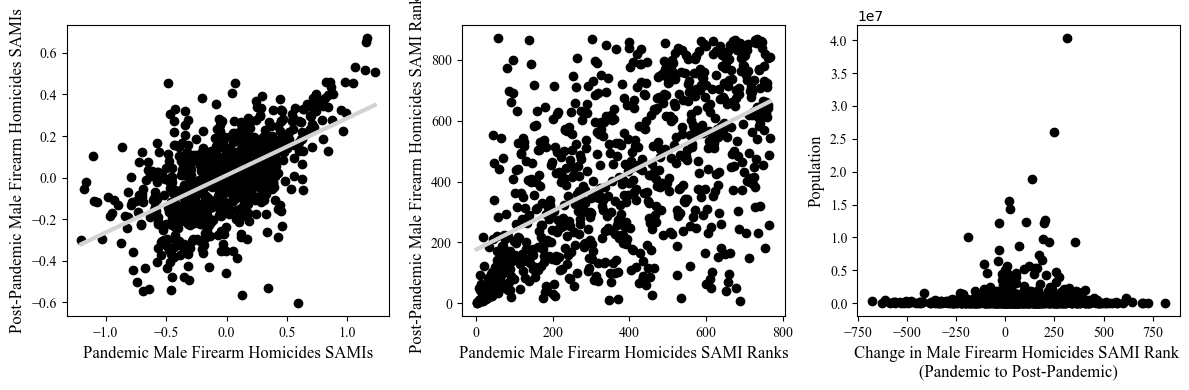

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# SAMI values
x = MSA_data["Male Firearm Homicides SAMIs II"]
y = MSA_data["Male Firearm Homicides SAMIs III"]
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x.iloc[:, 1], y) 
print(f"SAMI Values: Pearson's r = {r:.3f}, p = {p:.3e}")


ax = plt.subplot(1,3,1)
ax.scatter(MSA_data[["Male Firearm Homicides SAMIs II"]], MSA_data[["Male Firearm Homicides SAMIs III"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pandemic Male Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Post-Pandemic Male Firearm Homicides SAMIs", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

# SAMI Ranks

x = pd.to_numeric(MSA_data["Male Firearm Homicides SAMI Ranks II"], errors="coerce")
y = pd.to_numeric(MSA_data["Male Firearm Homicides SAMI Ranks III"], errors="coerce")
x = x.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)
valid = np.isfinite(x) & np.isfinite(y)
x = x[valid]
y = y[valid]
m, b = np.polyfit(x, y, 1) # Linear fit
y_pred = m * x + b # Predicted values
x_fit = np.linspace(x.min(), x.max(), 100) # Regression line
y_fit = m * x_fit + b # Regression line
x = sm.add_constant(x) # Add intercept
model = sm.OLS(y, x).fit() # Fit OLS regression
print(model.summary()) # Print full regression results

r, p = pearsonr(x[:, 1], y)
print(f"SAMI Ranks: Pearson's r = {r:.3f}, p = {p:.3e}")

ax = plt.subplot(1,3,2)
ax.scatter(MSA_data[["Male Firearm Homicides SAMI Ranks II"]], MSA_data[["Male Firearm Homicides SAMI Ranks III"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Pandemic Male Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Post-Pandemic Male Firearm Homicides SAMI Ranks", fontfamily="Times New Roman", fontsize=12)
ax.plot(x_fit, y_fit, color="lightgrey", linewidth=3)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

ax = plt.subplot(1,3,3)
ax.scatter(MSA_data[["Male Firearm Homicides SAMI Ranks III-II"]], MSA_data[["Population II"]], s=None, c="black", marker=None, alpha=None, linewidths=None, edgecolors="black")
ax.set_xlabel("Change in Male Firearm Homicides SAMI Rank \n(Pandemic to Post-Pandemic)", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Population", fontfamily="Times New Roman", fontsize=12)

plt.setp(ax.get_xticklabels(), fontfamily="Times New Roman")
plt.setp(ax.get_yticklabels(), fontfamily="Times New Roman")

fig.tight_layout()
plt.savefig('eFigure2jkl.pdf')
plt.show()


## Identidy cities with largest differences in SAMIs

In [55]:
top_10 = pd.DataFrame()
top_10["Firearm Homicides II-I"] = (MSA_data.nlargest(10, "Firearm Homicides SAMI Ranks II-I")["MSA Title"].reset_index(drop=True))
top_10["Female Firearm Homicides II-I"] = (MSA_data.nlargest(10, "Female Firearm Homicides SAMI Ranks II-I")["MSA Title"].reset_index(drop=True))
top_10["Male Firearm Homicides II-I"] = (MSA_data.nlargest(10, "Male Firearm Homicides SAMI Ranks II-I")["MSA Title"].reset_index(drop=True))
top_10["Firearm Homicides III-II"] = (MSA_data.nlargest(10, "Firearm Homicides SAMI Ranks III-II")["MSA Title"].reset_index(drop=True))
top_10["Female Firearm Homicides III-II"] = (MSA_data.nlargest(10, "Female Firearm Homicides SAMI Ranks III-II")["MSA Title"].reset_index(drop=True))
top_10["Male Firearm Homicides III-II"] = (MSA_data.nlargest(10, "Male Firearm Homicides SAMI Ranks III-II")["MSA Title"].reset_index(drop=True))
print(top_10)


       Firearm Homicides II-I Female Firearm Homicides II-I  \
0      Ponca City, OK MicroSA               Sebring, FL MSA   
1       Manitowoc, WI MicroSA     Cape Girardeau, MO-IL MSA   
2        Portales, NM MicroSA              Appleton, WI MSA   
3       Quincy, IL-MO MicroSA  Carlsbad-Artesia, NM MicroSA   
4         Sedalia, MO MicroSA            London, KY MicroSA   
5      Crossville, TN MicroSA           Rocky Mount, NC MSA   
6  Fredericksburg, TX MicroSA            Burlington, NC MSA   
7      Stillwater, OK MicroSA            Seneca, SC MicroSA   
8           Altus, OK MicroSA           Great Falls, MT MSA   
9           Keene, NH MicroSA             Wenatchee, WA MSA   

  Male Firearm Homicides II-I Firearm Homicides III-II  \
0       McAlester, OK MicroSA      Kennett, MO MicroSA   
1   Klamath Falls, OR MicroSA         Peru, IN MicroSA   
2       Quincy, IL-MO MicroSA    Levelland, TX MicroSA   
3          Marion, IN MicroSA        Jesup, GA MicroSA   
4       Sandpoin

In [56]:
bottom_10 = pd.DataFrame()
bottom_10["Firearm Homicides II-I"] = (MSA_data.nsmallest(10, "Firearm Homicides SAMI Ranks II-I")["MSA Title"].reset_index(drop=True))
bottom_10["Female Firearm Homicides II-I"] = (MSA_data.nsmallest(10, "Female Firearm Homicides SAMI Ranks II-I")["MSA Title"].reset_index(drop=True))
bottom_10["Male Firearm Homicides II-I"] = (MSA_data.nsmallest(10, "Male Firearm Homicides SAMI Ranks II-I")["MSA Title"].reset_index(drop=True))
bottom_10["Firearm Homicides III-II"] = (MSA_data.nsmallest(10, "Firearm Homicides SAMI Ranks III-II")["MSA Title"].reset_index(drop=True))
bottom_10["Female Firearm Homicides III-II"] = (MSA_data.nsmallest(10, "Female Firearm Homicides SAMI Ranks III-II")["MSA Title"].reset_index(drop=True))
bottom_10["Male Firearm Homicides III-II"] = (MSA_data.nsmallest(10, "Male Firearm Homicides SAMI Ranks III-II")["MSA Title"].reset_index(drop=True))
print(bottom_10)


     Firearm Homicides II-I Female Firearm Homicides II-I  \
0      Harrison, AR MicroSA            Wilmington, NC MSA   
1        Durant, OK MicroSA               Jackson, MI MSA   
2      Sheridan, WY MicroSA             Brunswick, GA MSA   
3     Thomaston, GA MicroSA                  Rome, GA MSA   
4  Madisonville, KY MicroSA        Orangeburg, SC MicroSA   
5          Peru, IN MicroSA                  Lima, OH MSA   
6        Ruston, LA MicroSA      Russellville, AR MicroSA   
7        Lufkin, TX MicroSA           Bloomington, IN MSA   
8         Rolla, MO MicroSA              New Bern, NC MSA   
9    Moses Lake, WA MicroSA              Dunn, NC MicroSA   

    Male Firearm Homicides II-I      Firearm Homicides III-II  \
0            Lufkin, TX MicroSA        Pottsville, PA MicroSA   
1         Corsicana, TX MicroSA              Prescott, AZ MSA   
2       Warrensburg, MO MicroSA  Butte-Silver Bow, MT MicroSA   
3         Thomaston, GA MicroSA           Pahrump, NV MicroSA   
4  

# Perform causal Analysis

### Make sure all columns are numeric

In [59]:
MSA_data["Licensed Dealerships SAMIs I"] = MSA_data["Licensed Dealerships SAMIs I"].apply(pd.to_numeric, errors="coerce")
MSA_data["Licensed Dealerships SAMIs II"] = MSA_data["Licensed Dealerships SAMIs II"].apply(pd.to_numeric, errors="coerce")
MSA_data["Licensed Dealerships SAMIs III"] = MSA_data["Licensed Dealerships SAMIs III"].apply(pd.to_numeric, errors="coerce")
MSA_data[["Domestic Violence Shelters SAMIs III"]] = MSA_data[["Domestic Violence Shelters SAMIs III"]].apply(pd.to_numeric, errors="coerce")


### FFH/MFH/DVS/FO/LD

0 1 [] 0.5039632516533702 6.580177926193644e-35
0 2 [] 0.33911410738768094 7.830067202731753e-17
0 3 [] 0.19881399283671547 9.05541767815384e-06
0 4 [] 0.10346839997499047 0.013373521440125198
1 2 [] 0.2697661692507527 1.6658462772475558e-13
1 3 [] 0.03195973501220292 0.4330232041008163
1 4 [] -0.0638226930902744 0.08636614695297254
2 3 [] -0.013393601530653481 0.7195729221860403
2 4 [] 0.20210678495129578 1.8389136023042077e-09
3 4 [] 0.1447155189967765 9.634224512433364e-05
0 1 [2] 0.4471858479518439 6.231519247923962e-27
0 1 [3] 0.5215139910989464 1.5310614908599688e-32
0 1 [4] 0.5141364963279262 2.000474611335173e-36
0 2 [1] 0.20255342957757455 3.221558519940475e-06
0 2 [3] 0.3573131788115794 3.3449388559696135e-16
0 2 [4] 0.324886782160966 1.7714821554611665e-15
0 3 [1] 0.2282518433542606 1.0782188628078167e-06
0 3 [2] 0.21352678488358204 1.8453510396158132e-06
0 3 [4] 0.17991984997688254 6.195074755263914e-05
0 4 [1] 0.1484792925122727 0.0006824215476738623
0 4 [2] 0.012061521536

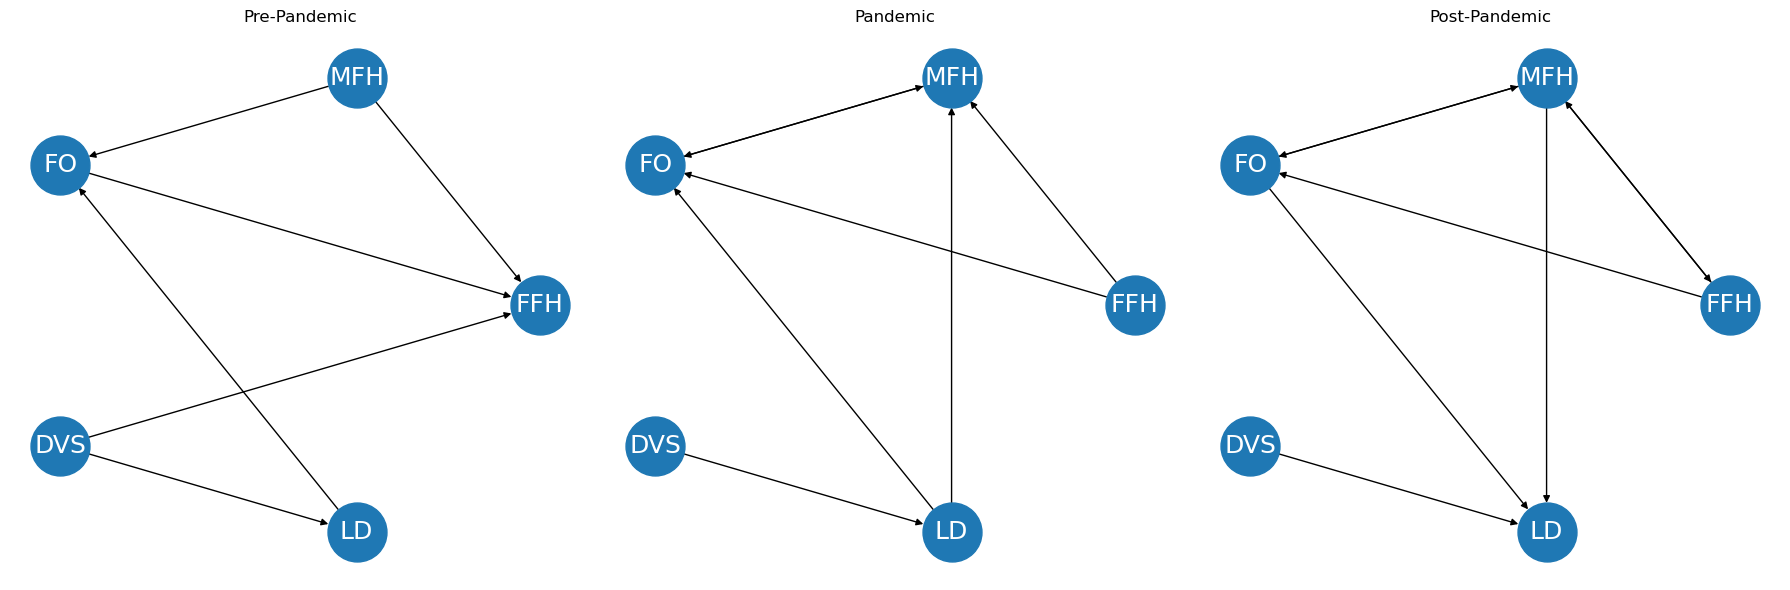

In [61]:
MAPPING_MI  = {k: v for k, v in zip(range(7), ["FFH","MFH","FO","DVS","LD"])}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs I","Male Firearm Homicides SAMIs I","Firearm Ownership SAMIs I","Domestic Violence Shelters SAMIs III","Licensed Dealerships SAMIs I"]])
learned_graph_MI_I = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_I  = nx.relabel_nodes(learned_graph_MI_I, MAPPING_MI, copy=True)

plt.sca(axes[0])
nx.draw_circular(learned_graph_MI_I,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[0].set_title("Pre-Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs II","Male Firearm Homicides SAMIs II","Firearm Ownership SAMIs II","Domestic Violence Shelters SAMIs III","Licensed Dealerships SAMIs II"]])

learned_graph_MI_II = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_II  = nx.relabel_nodes(learned_graph_MI_II, MAPPING_MI, copy=True)

plt.sca(axes[1])
nx.draw_circular(learned_graph_MI_II,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[1].set_title("Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs III","Male Firearm Homicides SAMIs III","Firearm Ownership SAMIs III","Domestic Violence Shelters SAMIs III","Licensed Dealerships SAMIs III"]])
learned_graph_MI_III = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_III  = nx.relabel_nodes(learned_graph_MI_III, MAPPING_MI, copy=True)

plt.sca(axes[2])
nx.draw_circular(learned_graph_MI_III,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[2].set_title("Post-Pandemic")

plt.tight_layout()
plt.savefig('Figure3.pdf')
plt.show()


### FFH/MFH/FO/LD

0 1 [] 0.5039632516533702 6.580177926193644e-35
0 2 [] 0.33911410738768094 7.830067202731753e-17
0 3 [] 0.10346839997499047 0.013373521440125198
1 2 [] 0.2697661692507527 1.6658462772475558e-13
1 3 [] -0.0638226930902744 0.08636614695297254
2 3 [] 0.20210678495129578 1.8389136023042077e-09
0 1 [2] 0.4471858479518439 6.231519247923962e-27
0 1 [3] 0.5141364963279262 2.000474611335173e-36
0 2 [1] 0.20255342957757455 3.221558519940475e-06
0 2 [3] 0.324886782160966 1.7714821554611665e-15
0 3 [1] 0.1484792925122727 0.0006824215476738623
0 3 [2] 0.012061521536085059 0.7738495536874449
1 2 [0] 0.18614839072882608 1.937137129152938e-05
2 3 [0] 0.2541812003109082 7.43378327858766e-10
2 3 [1] 0.2398412856891871 6.828659990501133e-11
2 3 [0, 1] 0.2861413400851007 3.0858111477098997e-11
0 1 [] 0.6061654787941386 1.7957134944879872e-58
0 2 [] 0.2890467794796451 4.5472556013097576e-13
0 3 [] 0.014260395892969274 0.7267362791296028
1 2 [] 0.30404376346758083 7.582662613909585e-18
1 3 [] -0.08533465023

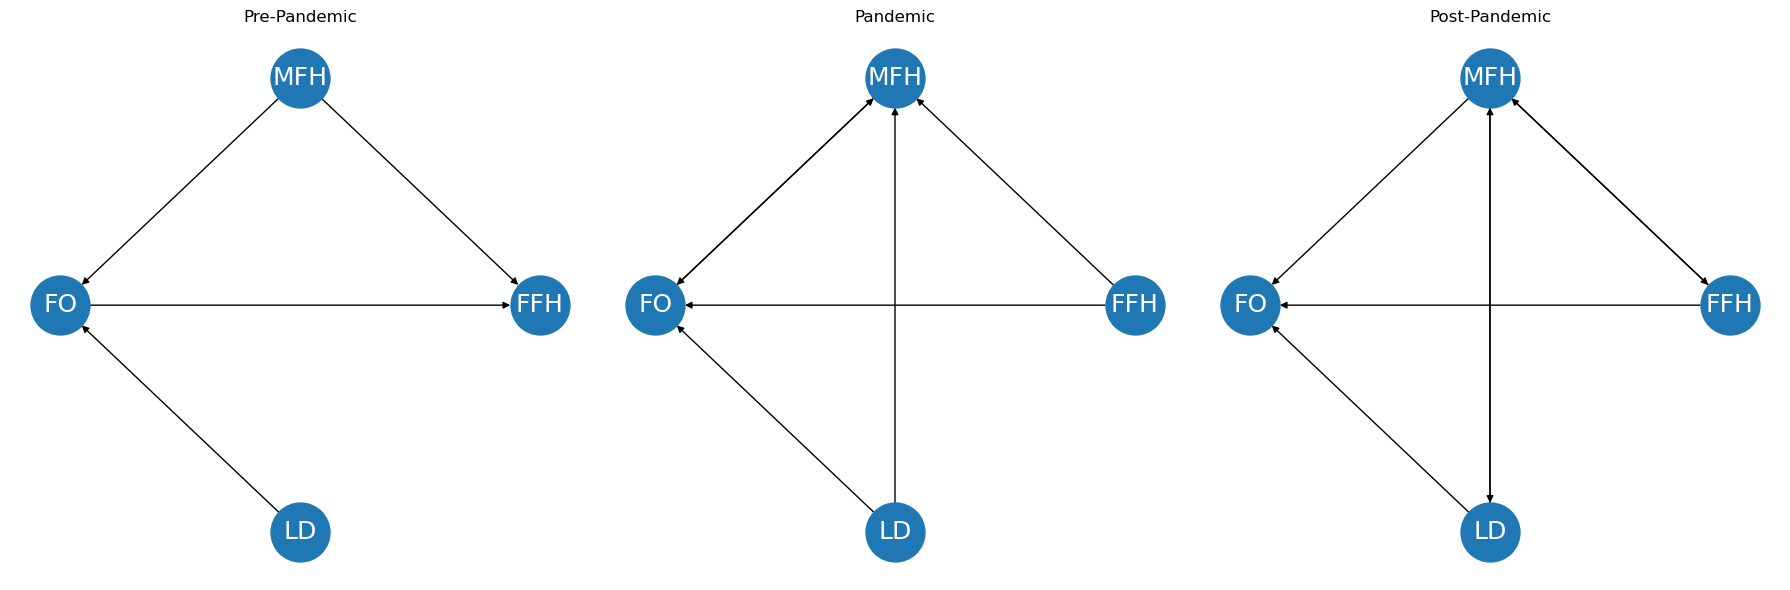

In [63]:
MAPPING_MI  = {k: v for k, v in zip(range(7), ["FFH","MFH","FO","LD"])}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs I","Male Firearm Homicides SAMIs I","Firearm Ownership SAMIs I","Licensed Dealerships SAMIs I"]])
learned_graph_MI_I = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_I  = nx.relabel_nodes(learned_graph_MI_I, MAPPING_MI, copy=True)

plt.sca(axes[0])
nx.draw_circular(learned_graph_MI_I,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[0].set_title("Pre-Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs II","Male Firearm Homicides SAMIs II","Firearm Ownership SAMIs II","Licensed Dealerships SAMIs II"]])
learned_graph_MI_II = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_II  = nx.relabel_nodes(learned_graph_MI_II, MAPPING_MI, copy=True)

plt.sca(axes[1])
nx.draw_circular(learned_graph_MI_II,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[1].set_title("Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs III","Male Firearm Homicides SAMIs III","Firearm Ownership SAMIs III","Licensed Dealerships SAMIs III"]])
learned_graph_MI_III = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_III  = nx.relabel_nodes(learned_graph_MI_III, MAPPING_MI, copy=True)

plt.sca(axes[2])
nx.draw_circular(learned_graph_MI_III,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[2].set_title("Post-Pandemic")

plt.tight_layout()
plt.savefig('eFigure3abc.pdf')
plt.show()


### FFH/MFH/FO/DVS

0 1 [] 0.5039632516533702 6.580177926193644e-35
0 2 [] 0.33911410738768094 7.830067202731753e-17
0 3 [] 0.19881399283671547 9.05541767815384e-06
1 2 [] 0.2697661692507527 1.6658462772475558e-13
1 3 [] 0.03195973501220292 0.4330232041008163
2 3 [] -0.013393601530653481 0.7195729221860403
0 1 [2] 0.4471858479518439 6.231519247923962e-27
0 1 [3] 0.5215139910989464 1.5310614908599688e-32
0 2 [1] 0.20255342957757455 3.221558519940475e-06
0 2 [3] 0.3573131788115794 3.3449388559696135e-16
0 3 [1] 0.2282518433542606 1.0782188628078167e-06
0 3 [2] 0.21352678488358204 1.8453510396158132e-06
1 2 [0] 0.18614839072882608 1.937137129152938e-05
0 1 [2, 3] 0.4703700953992221 6.206049906893138e-26
0 2 [1, 3] 0.23907912180230514 3.2360790187573866e-07
0 3 [1, 2] 0.24030847516002984 2.803217163909913e-07
0 1 [] 0.6061654787941386 1.7957134944879872e-58
0 2 [] 0.2890467794796451 4.5472556013097576e-13
0 3 [] 0.0831043533426491 0.05705177220842769
1 2 [] 0.30404376346758083 7.582662613909585e-18
1 3 [] 0.0

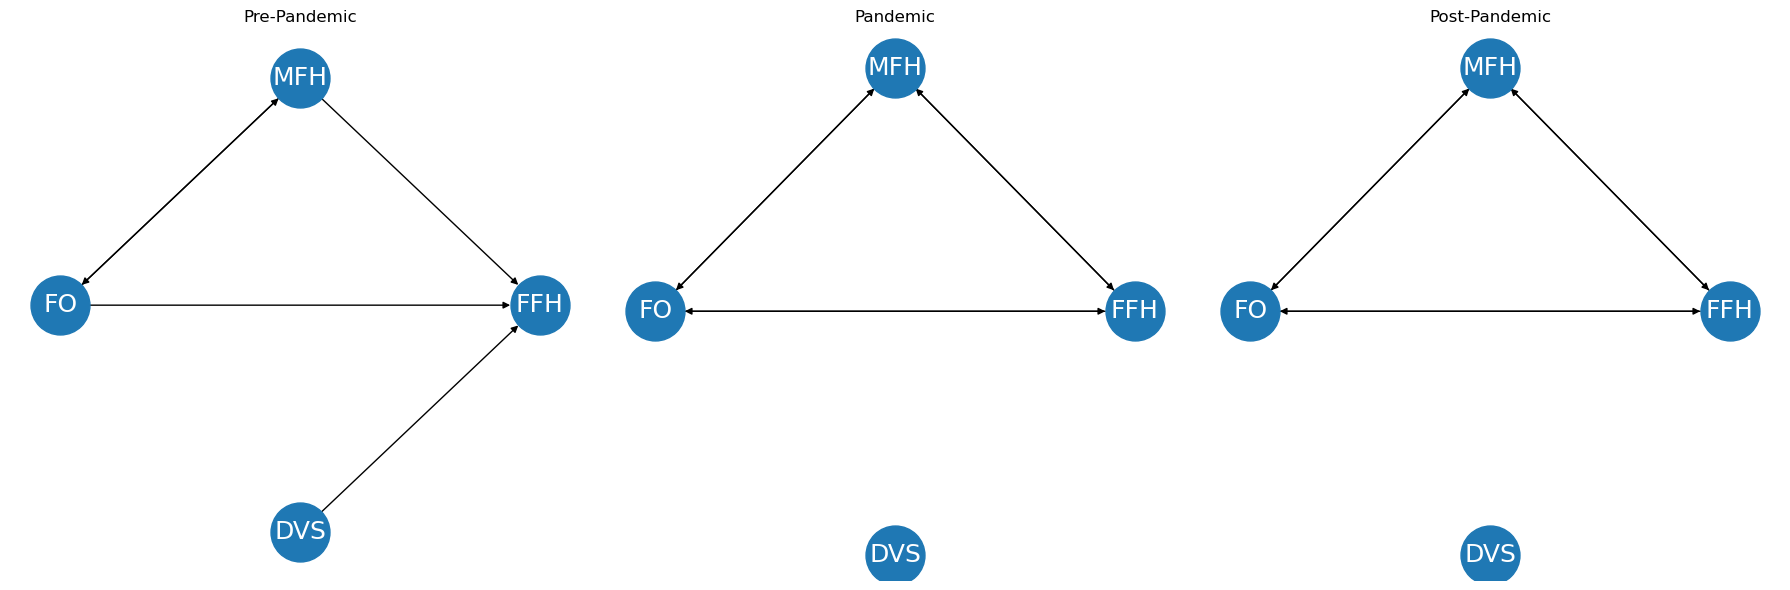

In [65]:
MAPPING_MI  = {k: v for k, v in zip(range(7), ["FFH","MFH","FO","DVS"])}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs I","Male Firearm Homicides SAMIs I","Firearm Ownership SAMIs I","Domestic Violence Shelters SAMIs III"]])
learned_graph_MI_I = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_I  = nx.relabel_nodes(learned_graph_MI_I, MAPPING_MI, copy=True)

plt.sca(axes[0])
nx.draw_circular(learned_graph_MI_I,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[0].set_title("Pre-Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs II","Male Firearm Homicides SAMIs II","Firearm Ownership SAMIs II","Domestic Violence Shelters SAMIs III"]])
learned_graph_MI_II = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_II  = nx.relabel_nodes(learned_graph_MI_II, MAPPING_MI, copy=True)

plt.sca(axes[1])
nx.draw_circular(learned_graph_MI_II,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[1].set_title("Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs III","Male Firearm Homicides SAMIs III","Firearm Ownership SAMIs III","Domestic Violence Shelters SAMIs III"]])
learned_graph_MI_III = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_III  = nx.relabel_nodes(learned_graph_MI_III, MAPPING_MI, copy=True)

plt.sca(axes[2])
nx.draw_circular(learned_graph_MI_III,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[2].set_title("Post-Pandemic")

plt.tight_layout()
plt.savefig('eFigure3def.pdf')
plt.show()


### FFH/DVS/FO/LD

0 1 [] 0.33911410738768094 7.830067202731753e-17
0 2 [] 0.19881399283671547 9.05541767815384e-06
0 3 [] 0.10346839997499047 0.013373521440125198
1 2 [] -0.013393601530653481 0.7195729221860403
1 3 [] 0.20210678495129578 1.8389136023042077e-09
2 3 [] 0.1447155189967765 9.634224512433364e-05
0 1 [2] 0.3573131788115794 3.3449388559696135e-16
0 1 [3] 0.324886782160966 1.7714821554611665e-15
0 2 [1] 0.21352678488358204 1.8453510396158132e-06
0 2 [3] 0.17991984997688254 6.195074755263914e-05
0 3 [1] 0.012061521536085059 0.7738495536874449
1 3 [0] 0.2541812003109082 7.43378327858766e-10
2 3 [0] 0.13866824092102598 0.002093838847711823
0 1 [] 0.2890467794796451 4.5472556013097576e-13
0 2 [] 0.0831043533426491 0.05705177220842769
0 3 [] 0.014260395892969274 0.7267362791296028
1 2 [] -0.04204158198254967 0.25956624061550254
1 3 [] 0.26120644396928877 5.067782097238805e-15
2 3 [] 0.15847170942174035 1.9126407679001878e-05
1 3 [0] 0.31019556098262874 6.8100368123429456e-15
0 1 [] 0.461488857287967

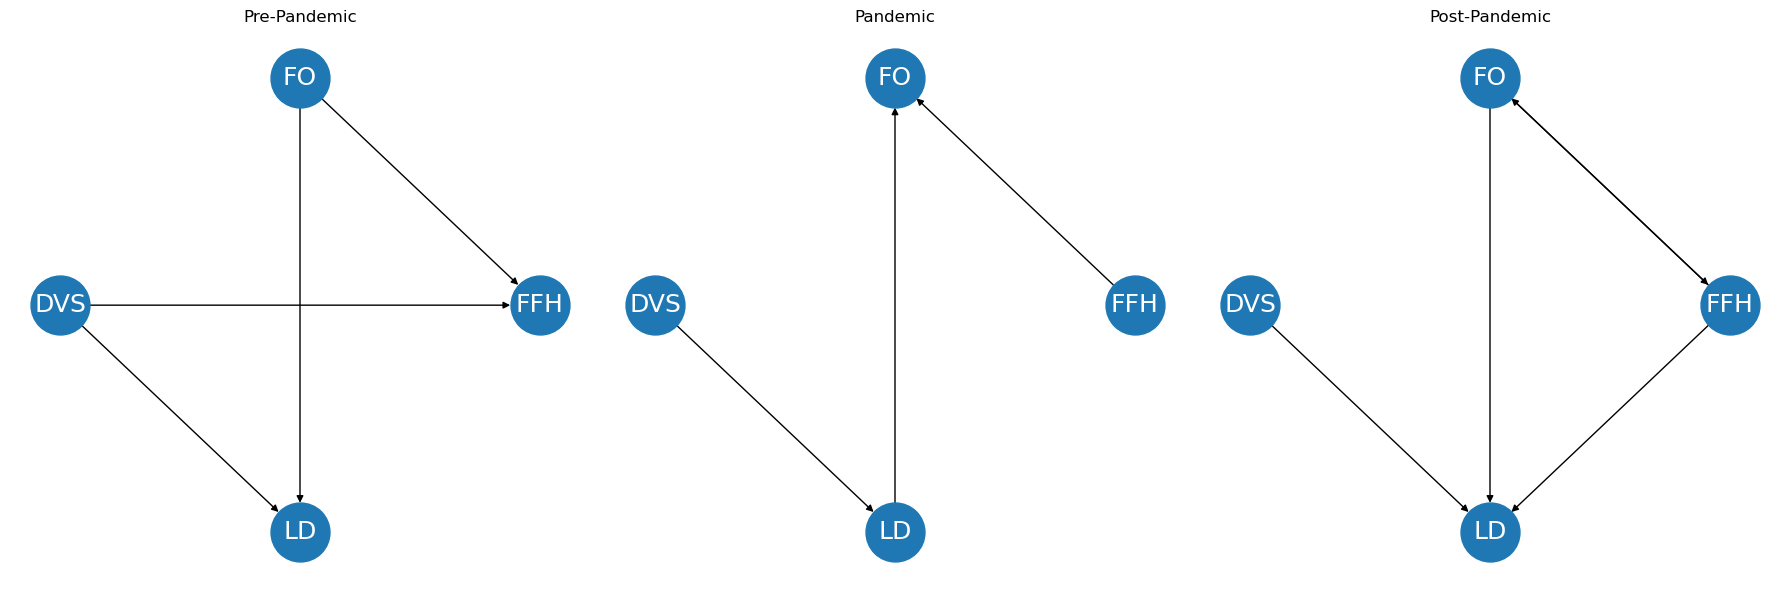

In [67]:
MAPPING_MI  = {k: v for k, v in zip(range(7), ["FFH","FO","DVS","LD"])}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs I","Firearm Ownership SAMIs I","Domestic Violence Shelters SAMIs III","Licensed Dealerships SAMIs I"]])
learned_graph_MI_I = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_I  = nx.relabel_nodes(learned_graph_MI_I, MAPPING_MI, copy=True)

plt.sca(axes[0])
nx.draw_circular(learned_graph_MI_I,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[0].set_title("Pre-Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs II","Firearm Ownership SAMIs II","Domestic Violence Shelters SAMIs III","Licensed Dealerships SAMIs II"]])

learned_graph_MI_II = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_II  = nx.relabel_nodes(learned_graph_MI_II, MAPPING_MI, copy=True)

plt.sca(axes[1])
nx.draw_circular(learned_graph_MI_II,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[1].set_title("Pandemic")

pc_MI = PC(ci_test = "Spearman")
pc_MI.learn(MSA_data[["Female Firearm Homicides SAMIs III","Firearm Ownership SAMIs III","Domestic Violence Shelters SAMIs III","Licensed Dealerships SAMIs III"]])
learned_graph_MI_III = nx.DiGraph(pc_MI.causal_matrix)
learned_graph_MI_III  = nx.relabel_nodes(learned_graph_MI_III, MAPPING_MI, copy=True)

plt.sca(axes[2])
nx.draw_circular(learned_graph_MI_III,with_labels=True,node_size=1800,font_size=18,font_color='white')
axes[2].set_title("Post-Pandemic")

plt.tight_layout()
plt.savefig('eFigure3ghi.pdf')
plt.show()
